In [2]:
# Cell M (UPDATED): MASTER REBUILD — with total_duration fix
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load JSON
with open("../data/trains.json", "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame([feat["properties"] for feat in data["features"]])

# 2. Clean
df = df.drop(columns=['return_train'])
df = df.dropna(subset=['distance'])
df['zone'] = df['zone'].replace('?', 'Unknown')
df['zone'] = df['zone'].astype(str).str.strip().replace('', 'Unknown')

# 3. Filter to 3 classes
df = df[df['type'].isin(['Pass', 'Exp', 'SF'])].copy()

# 4. *** TOTAL DURATION FIX ***
df['total_duration'] = df['duration_h'] * 60 + df['duration_m']

# 5. Keep final columns (total_duration instead of duration_m/h)
columns_to_keep = ['distance', 'total_duration', 'zone',
                   'sleeper', 'third_ac', 'second_ac', 'first_ac',
                   'chair_car', 'first_class', 'type']
df = df[columns_to_keep].copy()

# 6. One-hot encode zone
df_encoded = pd.get_dummies(df, columns=['zone'], dtype=int)

# 7. Separate X, y
X = df_encoded.drop(columns=['type'])
y = df_encoded['type']

# 8. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Save variables for later (for predict.py etc.)
import joblib
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.joblib')

print("✅ MASTER REBUILD COMPLETE")
print(f"   df shape         : {df.shape}")
print(f"   X_train_scaled   : {X_train_scaled.shape}")
print(f"   X_test_scaled    : {X_test_scaled.shape}")
print(f"   y_train          : {y_train.shape}")
print(f"   y_test           : {y_test.shape}")
print(f"   total_duration   : min={df['total_duration'].min():.0f}, max={df['total_duration'].max():.0f}, mean={df['total_duration'].mean():.0f}")

✅ MASTER REBUILD COMPLETE
   df shape         : (4466, 10)
   X_train_scaled   : (3572, 26)
   X_test_scaled    : (894, 26)
   y_train          : (3572,)
   y_test           : (894,)
   total_duration   : min=13, max=5130, mean=709


In [ ]:
# Cell 1: Environment Verification
# Ye cell check karega: Python version, libraries, aur data file

import sys
import os

print("=" * 50)
print("PYTHON VERSION")
print("=" * 50)
print(sys.version)
print()

print("=" * 50)
print("CURRENT WORKING DIRECTORY")
print("=" * 50)
print(os.getcwd())
print()

print("=" * 50)
print("LIBRARY CHECK")
print("=" * 50)
required_libs = ["pandas", "numpy", "matplotlib", "seaborn", "sklearn"]
for lib in required_libs:
    try:
        __import__(lib)
        print(f"OK       - {lib}")
    except ImportError:
        print(f"MISSING  - {lib}  (run: pip install {lib})")
print()

print("=" * 50)
print("DATA FILE CHECK")
print("=" * 50)
data_path = "../data/trains.json"
if os.path.exists(data_path):
    size_mb = os.path.getsize(data_path) / (1024 * 1024)
    print(f"OK       - {data_path} found")
    print(f"Size     - {size_mb:.2f} MB")
else:
    print(f"MISSING  - {data_path} not found")
    print("Check karo: data/trains.json notebook ke ek folder upar hona chahiye.")

PYTHON VERSION
3.13.6 (tags/v3.13.6:4e66535, Aug  6 2025, 14:36:00) [MSC v.1944 64 bit (AMD64)]

CURRENT WORKING DIRECTORY
c:\Prince\Indian-Railway-Train\notebooks

LIBRARY CHECK
OK       - pandas
OK       - numpy
OK       - matplotlib
OK       - seaborn
OK       - sklearn

DATA FILE CHECK
OK       - ../data/trains.json found
Size     - 14.08 MB


In [3]:
# Cell M: MASTER REBUILD — run this if kernel restarts
# Rebuilds: data → clean → X, y → split → scale → KMeans (k=4)
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load JSON
with open("../data/trains.json", "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame([feat["properties"] for feat in data["features"]])

# 2. Clean
df = df.drop(columns=['return_train'])
df = df.dropna(subset=['distance'])
df['zone'] = df['zone'].replace('?', 'Unknown')
df['zone'] = df['zone'].astype(str).str.strip().replace('', 'Unknown')

# 3. Filter to 3 classes
df = df[df['type'].isin(['Pass', 'Exp', 'SF'])].copy()

# 4. Drop leakage columns
columns_to_keep = ['distance', 'duration_m', 'zone',
                   'sleeper', 'third_ac', 'second_ac', 'first_ac',
                   'chair_car', 'first_class', 'type']
df = df[columns_to_keep].copy()

# 5. One-hot encode zone
df_encoded = pd.get_dummies(df, columns=['zone'], dtype=int)

# 6. Separate X, y
X = df_encoded.drop(columns=['type'])
y = df_encoded['type']

# 7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. KMeans (k=4)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled)

print("✅ MASTER REBUILD COMPLETE")
print(f"   X_train_scaled : {X_train_scaled.shape}")
print(f"   X_test_scaled  : {X_test_scaled.shape}")
print(f"   y_train        : {y_train.shape}")
print(f"   y_test         : {y_test.shape}")
print(f"   KMeans inertia : {kmeans_final.inertia_:.2f}")

✅ MASTER REBUILD COMPLETE
   X_train_scaled : (3572, 26)
   X_test_scaled  : (894, 26)
   y_train        : (3572,)
   y_test         : (894,)
   KMeans inertia : 74705.31


In [4]:
# Cell 2: Load JSON and inspect structure
import json

# Load the JSON file
with open("../data/trains.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Step 1: What is the top-level structure?
print("Top-level type :", type(data))
print("Top-level keys :", list(data.keys()))
print()

# Step 2: It should be a GeoJSON FeatureCollection
features = data["features"]
print("Total features (trains):", len(features))
print()

# Step 3: Look at ONE feature to understand the shape
first = features[0]
print("First feature keys:", list(first.keys()))
print()

# Step 4: What are the properties inside a train?
print("Properties inside the first train:")
for key, value in first["properties"].items():
    print(f"  {key}: {value}")

Top-level type : <class 'dict'>
Top-level keys : ['type', 'features']

Total features (trains): 5208

First feature keys: ['geometry', 'type', 'properties']

Properties inside the first train:
  third_ac: 0
  arrival: 12:15:00
  from_station_code: JAT
  name: Jammu Tawi Udhampur Special
  zone: NR
  chair_car: 0
  first_class: 0
  duration_m: 35
  sleeper: 0
  from_station_name: JAMMU TAWI
  number: 04601
  departure: 10:40:00
  return_train: 04602
  to_station_code: UHP
  second_ac: 0
  classes: 
  to_station_name: UDHAMPUR
  duration_h: 1
  type: DEMU
  first_ac: 0
  distance: 53


In [5]:
# Cell 3: Flatten JSON properties into a Pandas DataFrame
import pandas as pd

# Extract only the 'properties' part of each feature into a list of dicts
train_records = [feature["properties"] for feature in data["features"]]

# Convert list of dicts into a DataFrame
df = pd.DataFrame(train_records)

# Check the shape and columns
print("DataFrame shape (rows, columns):", df.shape)
print()
print("All columns:")
print(df.columns.tolist())
print()
print("First 5 rows:")
df.head()

DataFrame shape (rows, columns): (5208, 21)

All columns:
['third_ac', 'arrival', 'from_station_code', 'name', 'zone', 'chair_car', 'first_class', 'duration_m', 'sleeper', 'from_station_name', 'number', 'departure', 'return_train', 'to_station_code', 'second_ac', 'classes', 'to_station_name', 'duration_h', 'type', 'first_ac', 'distance']

First 5 rows:


,third_ac,arrival,from_station_code,name,zone,chair_car,first_class,duration_m,sleeper,from_station_name,...,departure,return_train,to_station_code,second_ac,classes,to_station_name,duration_h,type,first_ac,distance
0,0,12:15:00,JAT,Jammu Tawi Udhampur Special,NR,0,0,35.0,0,JAMMU TAWI,...,10:40:00,04602,UHP,0,,UDHAMPUR,1.0,DEMU,0,53.0
1,0,08:35:00,UHP,UDHAMPUR JAMMUTAWI DMU,NR,0,0,50.0,0,UDHAMPUR,...,06:45:00,04601,JAT,0,,JAMMU TAWI,1.0,DEMU,0,53.0
2,0,17:50:00,JAT,JAT UDAHMPUR DMU,NR,0,0,35.0,0,JAMMU TAWI,...,16:15:00,04604,UHP,0,,UDHAMPUR,1.0,DEMU,0,53.0
3,0,19:50:00,UHP,UDHAMPUR JAMMUTAWI DMU,NR,0,0,30.0,0,UDHAMPUR,...,18:20:00,04603,JAT,0,,JAMMU TAWI,1.0,DEMU,0,53.0
4,1,12:30:00,BDTS,Mumbai BandraT-Bikaner SF Special,NWR,0,0,55.0,1,MUMBAI BANDRA TERMINUS,...,14:35:00,04727,BKN,1,,BIKANER JN,21.0,SF,0,1212.0


In [6]:
# Cell 4: Inspect data types, non-null counts, and numeric summary
print("=" * 60)
print("DF.INFO() — Data types, non-null counts, memory")
print("=" * 60)
df.info()
print()

print("=" * 60)
print("DF.DESCRIBE() — Numeric columns ka summary")
print("=" * 60)
df.describe()

DF.INFO() — Data types, non-null counts, memory
<class 'pandas.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   third_ac           5208 non-null   int64  
 1   arrival            5208 non-null   str    
 2   from_station_code  5208 non-null   str    
 3   name               5208 non-null   str    
 4   zone               5208 non-null   str    
 5   chair_car          5208 non-null   int64  
 6   first_class        5208 non-null   int64  
 7   duration_m         5193 non-null   float64
 8   sleeper            5208 non-null   int64  
 9   from_station_name  5208 non-null   str    
 10  number             5208 non-null   str    
 11  departure          5208 non-null   str    
 12  return_train       4609 non-null   str    
 13  to_station_code    5208 non-null   str    
 14  second_ac          5208 non-null   int64  
 15  classes            5193 non-null   

,third_ac,chair_car,first_class,duration_m,sleeper,second_ac,duration_h,first_ac,distance
count,5208.000000,5208.000000,5208.000000,5193.000000,5208.000000,5208.000000,5193.000000,5208.000000,5193.000000
mean,0.316820,0.077381,0.032066,28.274408,0.337750,0.272081,10.766994,0.084293,544.769305
std,0.465281,0.267221,0.176192,17.294278,0.472988,0.445074,12.675426,0.277854,696.791114
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,2.000000,0.000000,88.000000
50%,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,6.000000,0.000000,227.000000
75%,1.000000,0.000000,0.000000,45.000000,1.000000,1.000000,15.000000,0.000000,693.000000
max,1.000000,1.000000,1.000000,58.000000,1.000000,1.000000,85.000000,1.000000,4279.000000


In [7]:
# Cell 5: Missing value count + zone ?/blank check
print("=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
missing = missing[missing > 0]  # sirf woh columns jo missing hain
print(missing)
print()

print("=" * 60)
print("ZONE COLUMN — unique values check")
print("=" * 60)
print("Total unique zones:", df['zone'].nunique())
print()
print("Zone value counts (top 20):")
print(df['zone'].value_counts().head(20))
print()

print("=" * 60)
print("ZONE mein '?' aur blank count")
print("=" * 60)
q_count = (df['zone'] == '?').sum()
blank_count = (df['zone'].astype(str).str.strip() == '').sum()
print(f"Rows with '?' in zone      : {q_count}")
print(f"Rows with blank/empty zone : {blank_count}")
print(f"Total suspicious           : {q_count + blank_count}")


MISSING VALUES PER COLUMN
duration_m       15
return_train    599
classes          15
duration_h       15
distance         15
dtype: int64

ZONE COLUMN — unique values check
Total unique zones: 19

Zone value counts (top 20):
zone
NR      628
SR      606
WR      470
SCR     437
NER     394
ER      369
CR      359
?       275
ECR     258
SER     251
NWR     232
SWR     227
NFR     219
NCR     135
ECoR    120
SECR    118
WCR      74
KR       21
         15
Name: count, dtype: int64

ZONE mein '?' aur blank count
Rows with '?' in zone      : 275
Rows with blank/empty zone : 15
Total suspicious           : 290


In [8]:
# Cell 6: Duplicate check + verify blank-zone rows = missing-distance rows
print("=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
dup_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")
print()

print("=" * 60)
print("CROSS-CHECK: zone blank (15) vs distance missing (15)")
print("=" * 60)
# Indices where distance is NaN
missing_distance_idx = set(df[df['distance'].isnull()].index)
# Indices where zone is blank (empty after strip)
blank_zone_idx = set(df[df['zone'].astype(str).str.strip() == ''].index)

print(f"Rows with distance missing : {len(missing_distance_idx)}")
print(f"Rows with zone blank       : {len(blank_zone_idx)}")
print(f"Same rows? (overlap count) : {len(missing_distance_idx & blank_zone_idx)}")
print()
print("Are they identical sets?", missing_distance_idx == blank_zone_idx)

DUPLICATE ROWS
Fully duplicated rows: 0

CROSS-CHECK: zone blank (15) vs distance missing (15)
Rows with distance missing : 15
Rows with zone blank       : 15
Same rows? (overlap count) : 15

Are they identical sets? True


## HANDOFF FROM PHASE 1 TO PHASE 2

### Phase 1 Objective:
Environment setup + data loading + data inspection (EDA ka pehla hissa)

### Completed (Cells 1–6):
- Cell 1: Environment verified
  - Python 3.13.6
  - Working directory: c:\Prince\Indian-Railway-Train\notebooks
  - Libraries OK: pandas, numpy, matplotlib, seaborn, sklearn
  - Data file found: ../data/trains.json (14.08 MB)
- Cell 2: trains.json loaded via json.load()
  - Top-level: dict with keys ['type', 'features']
  - Total features (trains): 5208
  - Each train = GeoJSON feature with 'properties' dict (21 fields)
- Cell 3: Flattened to DataFrame
  - Shape: (5208, 21)
  - Columns (21): third_ac, arrival, from_station_code, name, zone,
    chair_car, first_class, duration_m, sleeper, from_station_name,
    number, departure, return_train, to_station_code, second_ac,
    classes, to_station_name, duration_h, type, first_ac, distance
- Cell 4: df.info() + df.describe() documented
  - Dtypes: 6 int64, 3 float64, 12 str
  - Missing values detected in: duration_m (15), duration_h (15),
    distance (15), classes (15), return_train (599)
  - distance: mean 545 km, max 4279 km, min 0 km
  - duration_m: mean 28 min, max 58 min
- Cell 5: Missing values + zone '?'/blank count
  - Missing: distance=15, duration_m=15, duration_h=15, classes=15, return_train=599
  - zone unique values: 19 (17 real zones + '?' + blank)
  - zone '?' count: 275
  - zone blank count: 15
  - Total suspicious zone: 290
- Cell 6: Duplicates + cross-check
  - Duplicated rows: 0 ✅
  - Cross-check: 15 blank-zone rows = 15 missing-distance rows (identical sets) ✅

### Dataset State at End of Phase 1:
- File: data/trains.json (14.08 MB)
- Rows: 5208
- Columns: 21
- Target column: type — 16 unique values (Pass, Exp, SF, MEMU, Hyd,
  GR, Raj, Drnt, SKr, JShtb, Shtb, Mail, Toy, Del, DEMU, Klkt)
- Missing values: identified but NOT yet handled
- Duplicates: 0

### Key Findings (for report):
1. Dataset has clean structure (GeoJSON FeatureCollection)
2. 21 columns — mix of numeric, boolean flags, text, identifiers
3. Missing values concentrated in 5 columns; same 15 rows affected for
   4 columns (distance/duration_m/duration_h/classes)
4. zone has 290 problematic entries (275 '?', 15 blank)
5. return_train is 599/5208 = 11.5% missing — will be dropped
6. NO duplicate rows

### Known Issues / Decisions Pending:
- How to handle 15 rows with missing distance/duration → DROP (decided in Phase 2)
- How to handle zone '?'/blank → RECODE as 'Unknown' (decided in Phase 2)
- Duplicate count = 0 confirmed (assumption from prompt verified)

### Next Phase (Phase 2) Requirements:
- Apply cleaning decisions (drop 15 rows, recode zone, drop return_train)
- Filter type to 3 classes
- Drop leakage/irrelevant columns
- Encode zone
- Split + scale
- Baseline model

### Deliverables from Phase 1:
- Notebook cells 1–6 (working)
- Observations documented for report

### Academic Note:
- Phase 1 fulfills "EDA / Problem Definition" component (15 marks)
- Problem definition already submitted separately
- EDA plots (histograms, countplots) yet to be created — will be
  done after cleaning in Phase 2 as part of EDA finalization

In [9]:
# Cell 7: Apply cleaning decisions
# Remember the original shape for comparison
original_shape = df.shape
print("Original shape:", original_shape)
print()

# --- Step 1: Drop 'return_train' column (599 missing, not needed) ---
df = df.drop(columns=['return_train'])
print("After dropping 'return_train':", df.shape)
print()

# --- Step 2: Drop 15 rows where distance is missing ---
# (These are the same 15 rows that also have blank zone + missing duration_m/duration_h/classes)
before = df.shape[0]
df = df.dropna(subset=['distance'])
after = df.shape[0]
print(f"Rows before dropping missing-distance : {before}")
print(f"Rows after  dropping missing-distance : {after}")
print(f"Rows dropped                          : {before - after}")
print()

# --- Step 3: Recode zone '?' and blank as 'Unknown' ---
# First, verify what's left in zone after the row drop
q_count = (df['zone'] == '?').sum()
blank_count = (df['zone'].astype(str).str.strip() == '').sum()
print(f"Before recode -> '?' count: {q_count}, blank count: {blank_count}")

# Replace '?' with 'Unknown'
df['zone'] = df['zone'].replace('?', 'Unknown')
# Replace blank (empty string or whitespace-only) with 'Unknown'
df['zone'] = df['zone'].astype(str).str.strip().replace('', 'Unknown')

# Verify after recode
q_after = (df['zone'] == '?').sum()
blank_after = (df['zone'].astype(str).str.strip() == '').sum()
unknown_count = (df['zone'] == 'Unknown').sum()
print(f"After  recode -> '?' count: {q_after}, blank count: {blank_after}")
print(f"After  recode -> 'Unknown' count: {unknown_count}")
print()

# --- Final shape ---
print("Final shape:", df.shape)
print()
print("Zone value counts after cleaning:")
print(df['zone'].value_counts())

Original shape: (5208, 21)

After dropping 'return_train': (5208, 20)

Rows before dropping missing-distance : 5208
Rows after  dropping missing-distance : 5193
Rows dropped                          : 15

Before recode -> '?' count: 275, blank count: 0
After  recode -> '?' count: 0, blank count: 0
After  recode -> 'Unknown' count: 275

Final shape: (5193, 20)

Zone value counts after cleaning:
zone
NR         628
SR         606
WR         470
SCR        437
NER        394
ER         369
CR         359
Unknown    275
ECR        258
SER        251
NWR        232
SWR        227
NFR        219
NCR        135
ECoR       120
SECR       118
WCR         74
KR          21
Name: count, dtype: int64


In [10]:
# Cell 8: Filter type to 3 classes
print("=" * 60)
print("BEFORE FILTER — All type values")
print("=" * 60)
print("Total unique types:", df['type'].nunique())
print()
print("Type value counts (all):")
print(df['type'].value_counts())
print()

# --- Now filter to 3 classes ---
print("=" * 60)
print("APPLYING FILTER")
print("=" * 60)
target_classes = ['Passenger', 'Express', 'Superfast']
before_filter = df.shape[0]
df = df[df['type'].isin(target_classes)].copy()
after_filter = df.shape[0]

print(f"Rows before filter: {before_filter}")
print(f"Rows after  filter: {after_filter}")
print(f"Rows removed      : {before_filter - after_filter}")
print(f"Removed percentage: {100 * (before_filter - after_filter) / before_filter:.2f}%")
print()

print("=" * 60)
print("AFTER FILTER — 3 classes")
print("=" * 60)
print("Class distribution (count):")
print(df['type'].value_counts())
print()
print("Class distribution (%):")
print(df['type'].value_counts(normalize=True).mul(100).round(2))
print()
print("Final shape:", df.shape)

BEFORE FILTER — All type values
Total unique types: 16

Type value counts (all):
type
Pass     2459
Exp      1288
SF        719
MEMU      297
Hyd       121
GR         52
Raj        48
Drnt       48
SKr        42
JShtb      40
Shtb       31
Mail       19
Toy        14
Del         8
DEMU        4
Klkt        3
Name: count, dtype: int64

APPLYING FILTER
Rows before filter: 5193
Rows after  filter: 0
Rows removed      : 5193
Removed percentage: 100.00%

AFTER FILTER — 3 classes
Class distribution (count):
Series([], Name: count, dtype: int64)

Class distribution (%):
Series([], Name: proportion, dtype: float64)

Final shape: (0, 20)


In [11]:
# Cell 8-FIX: Reload df from memory and redo cleaning + correct filter
import pandas as pd

# --- Step 0: Rebuild df from the loaded JSON (data variable still in memory) ---
df = pd.DataFrame([f["properties"] for f in data["features"]])
print("Rebuilt from JSON — shape:", df.shape)
print()

# --- Step 1: Drop return_train column ---
df = df.drop(columns=['return_train'])
print("After dropping 'return_train':", df.shape)

# --- Step 2: Drop 15 rows with missing distance ---
df = df.dropna(subset=['distance'])
print("After dropping 15 missing-distance rows:", df.shape)

# --- Step 3: Recode zone '?' and blank as 'Unknown' ---
df['zone'] = df['zone'].replace('?', 'Unknown')
df['zone'] = df['zone'].astype(str).str.strip().replace('', 'Unknown')
print("Unknown in zone:", (df['zone'] == 'Unknown').sum())
print("Shape after cleaning:", df.shape)
print()

# --- Step 4: Filter type — CORRECT LABELS ---
# Pass = Passenger, Exp = Express, SF = Superfast
target_labels = ['Pass', 'Exp', 'SF']
before = df.shape[0]
df = df[df['type'].isin(target_labels)].copy()
after = df.shape[0]

print("=" * 60)
print("FILTER RESULT")
print("=" * 60)
print(f"Rows before filter: {before}")
print(f"Rows after  filter: {after}")
print(f"Rows removed      : {before - after}")
print()

print("Class distribution (count):")
print(df['type'].value_counts())
print()
print("Class distribution (%):")
print(df['type'].value_counts(normalize=True).mul(100).round(2))
print()
print("Final shape:", df.shape)

Rebuilt from JSON — shape: (5208, 21)

After dropping 'return_train': (5208, 20)
After dropping 15 missing-distance rows: (5193, 20)
Unknown in zone: 275
Shape after cleaning: (5193, 20)

FILTER RESULT
Rows before filter: 5193
Rows after  filter: 4466
Rows removed      : 727

Class distribution (count):
type
Pass    2459
Exp     1288
SF       719
Name: count, dtype: int64

Class distribution (%):
type
Pass    55.06
Exp     28.84
SF      16.10
Name: proportion, dtype: float64

Final shape: (4466, 20)


In [12]:
# Cell 9: Drop leakage + irrelevant columns; keep only final feature set + target
# Locked contract (Section 8):
# Features (9): distance, duration_m, zone, sleeper, third_ac, second_ac, first_ac, chair_car, first_class
# Target: type

columns_to_keep = [
    'distance', 'duration_m', 'zone',
    'sleeper', 'third_ac', 'second_ac', 'first_ac', 'chair_car', 'first_class',
    'type'
]

columns_to_drop = [col for col in df.columns if col not in columns_to_keep]

print("=" * 60)
print("COLUMNS BEING DROPPED (leakage or irrelevant)")
print("=" * 60)
for col in columns_to_drop:
    print(f"  - {col}")
print()
print(f"Total dropped: {len(columns_to_drop)}")
print()

# Keep only the final feature set + target
df = df[columns_to_keep].copy()

print("=" * 60)
print("REMAINING COLUMNS (Final feature set + target)")
print("=" * 60)
print(df.columns.tolist())
print()
print("Shape:", df.shape)
print()
print("First 3 rows:")
df.head(3)

COLUMNS BEING DROPPED (leakage or irrelevant)
  - arrival
  - from_station_code
  - name
  - from_station_name
  - number
  - departure
  - to_station_code
  - classes
  - to_station_name
  - duration_h

Total dropped: 10

REMAINING COLUMNS (Final feature set + target)
['distance', 'duration_m', 'zone', 'sleeper', 'third_ac', 'second_ac', 'first_ac', 'chair_car', 'first_class', 'type']

Shape: (4466, 10)

First 3 rows:


,distance,duration_m,zone,sleeper,third_ac,second_ac,first_ac,chair_car,first_class,type
4,1212.0,55.0,NWR,1,1,1,0,0,0,SF
5,82.0,35.0,Unknown,0,0,0,0,0,0,Pass
6,82.0,50.0,Unknown,0,0,0,0,0,0,Pass


In [13]:
# Cell 10: One-hot encode zone + separate X (features) and y (target)
import pandas as pd

print("=" * 60)
print("BEFORE ENCODING")
print("=" * 60)
print("Shape:", df.shape)
print("Zone unique values:", df['zone'].nunique())
print()

# --- Step 1: One-hot encode 'zone' ---
# pd.get_dummies creates a new 0/1 column for each zone value
# dtype=int ensures 0/1 (not True/False) — cleaner for later
df_encoded = pd.get_dummies(df, columns=['zone'], dtype=int)

print("=" * 60)
print("AFTER ONE-HOT ENCODING")
print("=" * 60)
print("Shape:", df_encoded.shape)
print()
print("All columns after encoding:")
for col in df_encoded.columns:
    print(f"  {col}")
print()

# --- Step 2: Separate X (features) and y (target) ---
X = df_encoded.drop(columns=['type'])
y = df_encoded['type']

print("=" * 60)
print("X and y SEPARATED")
print("=" * 60)
print("X shape (features):", X.shape)
print("y shape (target)  :", y.shape)
print()
print("X columns (features going into the model):")
print(X.columns.tolist())
print()
print("y unique values (target classes):")
print(y.unique())
print()
print("y value counts:")
print(y.value_counts())

BEFORE ENCODING
Shape: (4466, 10)
Zone unique values: 18

AFTER ONE-HOT ENCODING
Shape: (4466, 27)

All columns after encoding:
  distance
  duration_m
  sleeper
  third_ac
  second_ac
  first_ac
  chair_car
  first_class
  type
  zone_CR
  zone_ECR
  zone_ECoR
  zone_ER
  zone_KR
  zone_NCR
  zone_NER
  zone_NFR
  zone_NR
  zone_NWR
  zone_SCR
  zone_SECR
  zone_SER
  zone_SR
  zone_SWR
  zone_Unknown
  zone_WCR
  zone_WR

X and y SEPARATED
X shape (features): (4466, 26)
y shape (target)  : (4466,)

X columns (features going into the model):
['distance', 'duration_m', 'sleeper', 'third_ac', 'second_ac', 'first_ac', 'chair_car', 'first_class', 'zone_CR', 'zone_ECR', 'zone_ECoR', 'zone_ER', 'zone_KR', 'zone_NCR', 'zone_NER', 'zone_NFR', 'zone_NR', 'zone_NWR', 'zone_SCR', 'zone_SECR', 'zone_SER', 'zone_SR', 'zone_SWR', 'zone_Unknown', 'zone_WCR', 'zone_WR']

y unique values (target classes):
<StringArray>
['SF', 'Pass', 'Exp']
Length: 3, dtype: str

y value counts:
type
Pass    2459
Exp 

In [14]:
# Cell 11: Train/Test Split (stratified, before scaling)
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% test
# stratify=y ensures both sets have same class proportion
# random_state=42 for reproducibility (Section 8 — locked)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("SPLIT DONE")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")
print()

print("=" * 60)
print("CLASS BALANCE CHECK — Train vs Test")
print("=" * 60)
print("Train class distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print()
print("Test class distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))
print()

print("=" * 60)
print("Verify: No data leakage")
print("=" * 60)
print("'name' in X_train columns?", 'name' in X_train.columns)
print("X_train and X_test have same columns?", list(X_train.columns) == list(X_test.columns))

SPLIT DONE
X_train shape: (3572, 26)
X_test  shape: (894, 26)
y_train shape: (3572,)
y_test  shape: (894,)

CLASS BALANCE CHECK — Train vs Test
Train class distribution (%):
type
Pass    55.07
Exp     28.84
SF      16.10
Name: proportion, dtype: float64

Test class distribution (%):
type
Pass    55.03
Exp     28.86
SF      16.11
Name: proportion, dtype: float64

Verify: No data leakage
'name' in X_train columns? False
X_train and X_test have same columns? True


In [15]:
# Cell 12: StandardScaler — fit on train, transform both
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- Create scaler ---
scaler = StandardScaler()

# --- Fit ONLY on training data ---
# fit_transform: learns mean/std from train AND scales train in one shot
X_train_scaled = scaler.fit_transform(X_train)

# --- Transform test using the SAME scaler (no re-fit!) ---
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("SCALING DONE")
print("=" * 60)
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")
print()

# --- Verify: training data should have mean ~0, std ~1 ---
print("=" * 60)
print("SCALING SANITY CHECK (on training data)")
print("=" * 60)
# Convert back to DataFrame for readable stats
train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("First 5 features — mean and std after scaling:")
print(train_scaled_df[['distance', 'duration_m', 'sleeper', 'third_ac', 'second_ac']].describe().loc[['mean', 'std']])
print()

print("=" * 60)
print("TEST DATA STATS (should NOT be exactly 0/1)")
print("=" * 60)
test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("First 5 features — mean and std on test:")
print(test_scaled_df[['distance', 'duration_m', 'sleeper', 'third_ac', 'second_ac']].describe().loc[['mean', 'std']])

SCALING DONE
X_train_scaled shape: (3572, 26)
X_test_scaled  shape: (894, 26)

SCALING SANITY CHECK (on training data)
First 5 features — mean and std after scaling:
          distance    duration_m       sleeper      third_ac     second_ac
mean -5.072464e-17  5.967604e-17 -2.983802e-17  2.784882e-17 -5.569764e-17
std   1.000140e+00  1.000140e+00  1.000140e+00  1.000140e+00  1.000140e+00

TEST DATA STATS (should NOT be exactly 0/1)
First 5 features — mean and std on test:
      distance  duration_m   sleeper  third_ac  second_ac
mean  0.022657    0.009348 -0.031427  0.006399   0.002390
std   1.034900    1.018538  0.992173  1.002950   1.001693


In [16]:
# Cell 13: Baseline DummyClassifier
# Ye model har baar sirf sabse common class (Pass) predict karega
# Iska F1 humari "minimum acceptable line" hai

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Strategy: 'most_frequent' = always predict the most common class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

print("=" * 60)
print("BASELINE — DummyClassifier (always predicts 'Pass')")
print("=" * 60)
print(f"Accuracy          : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1 (macro)        : {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")
print(f"F1 (weighted)     : {f1_score(y_test, y_pred_dummy, average='weighted'):.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred_dummy))

BASELINE — DummyClassifier (always predicts 'Pass')
Accuracy          : 0.5503
F1 (macro)        : 0.2367
F1 (weighted)     : 0.3907

Full classification report:
              precision    recall  f1-score   support

         Exp       0.00      0.00      0.00       258
        Pass       0.55      1.00      0.71       492
          SF       0.00      0.00      0.00       144

    accuracy                           0.55       894
   macro avg       0.18      0.33      0.24       894
weighted avg       0.30      0.55      0.39       894



c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## HANDOFF FROM PHASE 2 TO PHASE 3

### Completed:
- Data loaded, cleaned, filtered to 3 classes
- X (26 features), y (3 classes) ready
- Train/test split: 3572/894, stratified
- StandardScaler: fit on train, transformed both
- Baseline: DummyClassifier — F1 macro 0.2367

### Dataset State:
- Rows: 4466 (after filter)
- Features: 26 (distance, duration_m, 8 coach flags, 18 zone one-hot columns)
- Class balance: Pass 55% / Exp 29% / SF 16%
- Missing values: 0
- Leakage check: PASSED (no name, split before scale)

### Configuration:
- random_state: 42 (everywhere)
- Primary metric: F1 (macro) — kyunki class imbalance hai
- Scaler: fit on train only

### Next Phase Requirements:
- X_train_scaled, X_test_scaled, y_train, y_test ready
- Baseline F1 to beat: 0.2367

In [19]:
# Cell 14: Model 1 — K-Nearest Neighbors (k=5)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- Train KNN with k=5 ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# --- Predict on test ---
y_pred_knn = knn.predict(X_test_scaled)

print("=" * 60)
print("MODEL 1 — KNN (k=5)")
print("=" * 60)
print(f"Accuracy       : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1 (macro)     : {f1_score(y_test, y_pred_knn, average='macro'):.4f}")
print(f"F1 (weighted)  : {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_knn, average='macro'):.4f}")
print(f"Recall (macro)   : {recall_score(y_test, y_pred_knn, average='macro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))
print()
print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(confusion_matrix(y_test, y_pred_knn))

MODEL 1 — KNN (k=5)
Accuracy       : 0.8300
F1 (macro)     : 0.7552
F1 (weighted)  : 0.8245
Precision (macro): 0.7658
Recall (macro)   : 0.7472

Classification Report:
              precision    recall  f1-score   support

         Exp       0.73      0.67      0.70       258
        Pass       0.92      0.98      0.95       492
          SF       0.65      0.58      0.61       144

    accuracy                           0.83       894
   macro avg       0.77      0.75      0.76       894
weighted avg       0.82      0.83      0.82       894


Confusion Matrix:
Rows = Actual, Columns = Predicted
[[174  39  45]
 [  7 484   1]
 [ 57   3  84]]


In [20]:
# Cell 15: Model 2 — Decision Tree (default hyperparameters)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- Train Decision Tree ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_dt = dt.predict(X_test_scaled)

print("=" * 60)
print("MODEL 2 — Decision Tree (default)")
print("=" * 60)
print(f"Accuracy       : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1 (macro)     : {f1_score(y_test, y_pred_dt, average='macro'):.4f}")
print(f"F1 (weighted)  : {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_dt, average='macro'):.4f}")
print(f"Recall (macro)   : {recall_score(y_test, y_pred_dt, average='macro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
print()
print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(confusion_matrix(y_test, y_pred_dt))
print()
print(f"Tree depth (default): {dt.get_depth()}")
print(f"Number of leaves    : {dt.get_n_leaves()}")

MODEL 2 — Decision Tree (default)
Accuracy       : 0.8702
F1 (macro)     : 0.8309
F1 (weighted)  : 0.8711
Precision (macro): 0.8274
Recall (macro)   : 0.8346

Classification Report:
              precision    recall  f1-score   support

         Exp       0.78      0.78      0.78       258
        Pass       0.96      0.94      0.95       492
          SF       0.75      0.78      0.76       144

    accuracy                           0.87       894
   macro avg       0.83      0.83      0.83       894
weighted avg       0.87      0.87      0.87       894


Confusion Matrix:
Rows = Actual, Columns = Predicted
[[202  20  36]
 [ 26 464   2]
 [ 32   0 112]]

Tree depth (default): 29
Number of leaves    : 608


In [21]:
# Cell 16: Decision Tree tuned (max_depth=10 to reduce overfitting)
dt_tuned = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_tuned.fit(X_train_scaled, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test_scaled)

print("=" * 60)
print("MODEL 2b — Decision Tree (max_depth=10)")
print("=" * 60)
print(f"Accuracy       : {accuracy_score(y_test, y_pred_dt_tuned):.4f}")
print(f"F1 (macro)     : {f1_score(y_test, y_pred_dt_tuned, average='macro'):.4f}")
print(f"F1 (weighted)  : {f1_score(y_test, y_pred_dt_tuned, average='weighted'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_tuned))
print()
print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(confusion_matrix(y_test, y_pred_dt_tuned))
print()
print(f"Tree depth (tuned): {dt_tuned.get_depth()}")
print(f"Number of leaves  : {dt_tuned.get_n_leaves()}")

MODEL 2b — Decision Tree (max_depth=10)
Accuracy       : 0.8445
F1 (macro)     : 0.7720
F1 (weighted)  : 0.8396

Classification Report:
              precision    recall  f1-score   support

         Exp       0.72      0.76      0.74       258
        Pass       0.94      0.98      0.96       492
          SF       0.71      0.55      0.62       144

    accuracy                           0.84       894
   macro avg       0.79      0.76      0.77       894
weighted avg       0.84      0.84      0.84       894


Confusion Matrix:
Rows = Actual, Columns = Predicted
[[195  31  32]
 [ 11 481   0]
 [ 63   2  79]]

Tree depth (tuned): 10
Number of leaves  : 225


In [22]:
# Cell 17: Model 3 — Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- Train GaussianNB ---
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_nb = nb.predict(X_test_scaled)

print("=" * 60)
print("MODEL 3 — Gaussian Naive Bayes")
print("=" * 60)
print(f"Accuracy       : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1 (macro)     : {f1_score(y_test, y_pred_nb, average='macro'):.4f}")
print(f"F1 (weighted)  : {f1_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_nb, average='macro'):.4f}")
print(f"Recall (macro)   : {recall_score(y_test, y_pred_nb, average='macro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))
print()
print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(confusion_matrix(y_test, y_pred_nb))

MODEL 3 — Gaussian Naive Bayes
Accuracy       : 0.3535
F1 (macro)     : 0.2969
F1 (weighted)  : 0.3448
Precision (macro): 0.6054
Recall (macro)   : 0.4515

Classification Report:
              precision    recall  f1-score   support

         Exp       0.67      0.03      0.06       258
        Pass       0.95      0.34      0.50       492
          SF       0.20      0.99      0.33       144

    accuracy                           0.35       894
   macro avg       0.61      0.45      0.30       894
weighted avg       0.75      0.35      0.34       894


Confusion Matrix:
Rows = Actual, Columns = Predicted
[[  8   9 241]
 [  2 166 324]
 [  2   0 142]]


In [23]:
# Cell 18: Model 4 — SVM (Support Vector Machine)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- Train SVM ---
# Default kernel='rbf', C=1.0
# max_iter=2000 for safety against convergence warnings
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_svm = svm.predict(X_test_scaled)

print("=" * 60)
print("MODEL 4 — SVM (RBF kernel)")
print("=" * 60)
print(f"Accuracy       : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1 (macro)     : {f1_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"F1 (weighted)  : {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"Recall (macro)   : {recall_score(y_test, y_pred_svm, average='macro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))
print()
print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(confusion_matrix(y_test, y_pred_svm))

MODEL 4 — SVM (RBF kernel)
Accuracy       : 0.8177
F1 (macro)     : 0.7168
F1 (weighted)  : 0.8058
Precision (macro): 0.7575
Recall (macro)   : 0.7049

Classification Report:
              precision    recall  f1-score   support

         Exp       0.67      0.74      0.71       258
        Pass       0.92      0.98      0.95       492
          SF       0.68      0.39      0.50       144

    accuracy                           0.82       894
   macro avg       0.76      0.70      0.72       894
weighted avg       0.81      0.82      0.81       894


Confusion Matrix:
Rows = Actual, Columns = Predicted
[[192  41  25]
 [  8 483   1]
 [ 86   2  56]]


MODEL COMPARISON TABLE
           Model  Accuracy  F1 (macro)  F1 (weighted)
Baseline (Dummy)    0.5503      0.2367         0.3907
       KNN (k=5)    0.8300      0.7552         0.8245
    DT (default)    0.8702      0.8309         0.8711
   DT (depth=10)    0.8445      0.7720         0.8396
     Naive Bayes    0.3535      0.2969         0.3448
       SVM (RBF)    0.8177      0.7168         0.8058



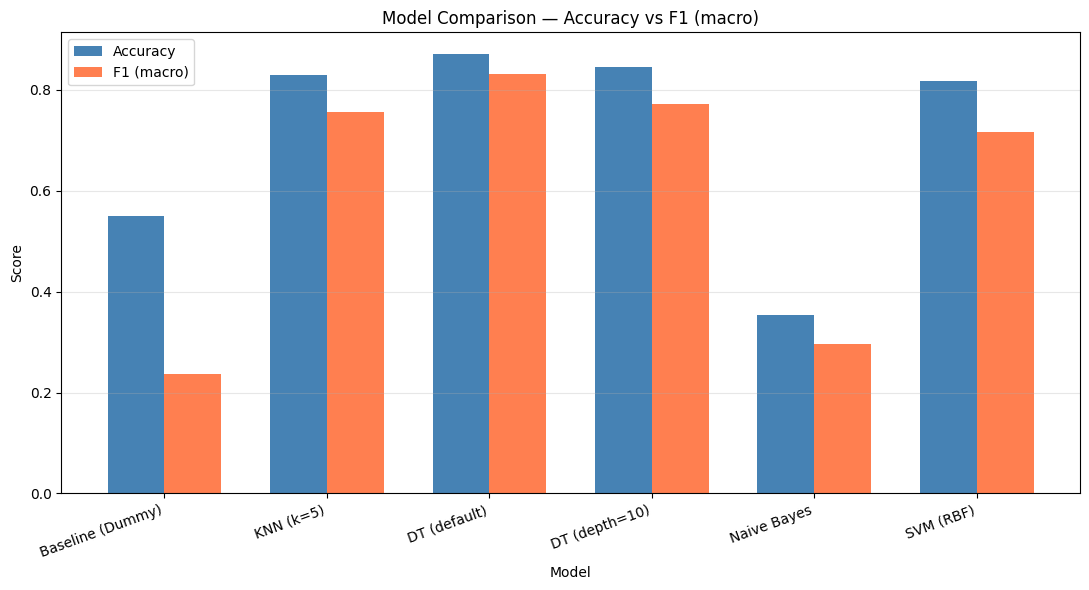

Plot saved to ../visualizations/model_comparison.png


In [24]:
# Cell 19: Model comparison table + bar chart
import pandas as pd
import matplotlib.pyplot as plt

# --- Build comparison table ---
results = pd.DataFrame({
    'Model': ['Baseline (Dummy)', 'KNN (k=5)', 'DT (default)', 'DT (depth=10)', 'Naive Bayes', 'SVM (RBF)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
    ],
    'F1 (macro)': [
        f1_score(y_test, y_pred_dummy, average='macro'),
        f1_score(y_test, y_pred_knn, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_dt_tuned, average='macro'),
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
    ],
    'F1 (weighted)': [
        f1_score(y_test, y_pred_dummy, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_dt_tuned, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
    ],
})

# Round for readability
results[['Accuracy', 'F1 (macro)', 'F1 (weighted)']] = results[['Accuracy', 'F1 (macro)', 'F1 (weighted)']].round(4)

print("=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(results.to_string(index=False))
print()

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(results))
width = 0.35

ax.bar([i - width/2 for i in x], results['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar([i + width/2 for i in x], results['F1 (macro)'], width, label='F1 (macro)', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy vs F1 (macro)')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved to ../visualizations/model_comparison.png")

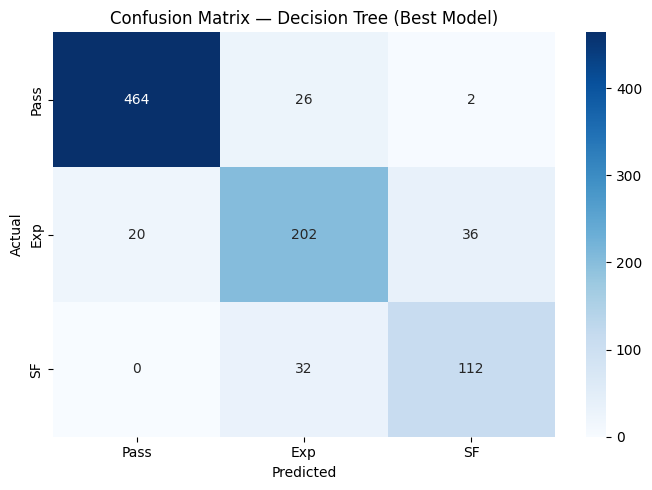

Confusion Matrix (rows=Actual, cols=Predicted):
                Predicted
                Pass  Exp  SF
Actual  Pass     464   26    2
        Exp       20  202   36
        SF         0   32  112

Interpretation:
- Pass correctly identified    : 464/492 (94.3%)
- Exp  correctly identified    : 202/258 (78.3%)
- SF   correctly identified    : 112/144 (77.8%)
- Biggest mistake: Exp predicted as SF -> 36 times
- Second mistake: SF predicted as Exp  -> 32 times


In [25]:
# Cell 20: Confusion matrix heatmap for best model (DT default)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Compute confusion matrix ---
cm = confusion_matrix(y_test, y_pred_dt, labels=['Pass', 'Exp', 'SF'])

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pass', 'Exp', 'SF'],
    yticklabels=['Pass', 'Exp', 'SF'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Decision Tree (Best Model)')

plt.tight_layout()
plt.savefig('../visualizations/confusion_matrix_best.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Print interpretation ---
print("Confusion Matrix (rows=Actual, cols=Predicted):")
print("                Predicted")
print("                Pass  Exp  SF")
print(f"Actual  Pass    {cm[0][0]:>4} {cm[0][1]:>4} {cm[0][2]:>4}")
print(f"        Exp     {cm[1][0]:>4} {cm[1][1]:>4} {cm[1][2]:>4}")
print(f"        SF      {cm[2][0]:>4} {cm[2][1]:>4} {cm[2][2]:>4}")
print()
print("Interpretation:")
print(f"- Pass correctly identified    : {cm[0][0]}/492 ({100*cm[0][0]/492:.1f}%)")
print(f"- Exp  correctly identified    : {cm[1][1]}/258 ({100*cm[1][1]/258:.1f}%)")
print(f"- SF   correctly identified    : {cm[2][2]}/144 ({100*cm[2][2]/144:.1f}%)")
print(f"- Biggest mistake: Exp predicted as SF -> {cm[1][2]} times")
print(f"- Second mistake: SF predicted as Exp  -> {cm[2][1]} times")

## HANDOFF FROM PHASE 3 TO PHASE 4

### Phase 3 Objective:
Supervised models train + evaluate + compare

### Completed (Cells 14–20):
- Cell 14: KNN (k=5) — Acc 0.8300, F1 macro 0.7552
- Cell 15: Decision Tree (default) — Acc 0.8702, F1 macro 0.8309 🏆
- Cell 16: Decision Tree (max_depth=10) — Acc 0.8445, F1 macro 0.7720
- Cell 17: Naive Bayes (GaussianNB) — Acc 0.3535, F1 macro 0.2969 ❌
- Cell 18: SVM (RBF) — Acc 0.8177, F1 macro 0.7168
- Cell 19: Comparison table + bar chart → visualizations/model_comparison.png
- Cell 20: Confusion matrix heatmap (best model) → visualizations/confusion_matrix_best.png

### Results Summary:
| Model | Accuracy | F1 (macro) | F1 (weighted) |
|-------|----------|------------|---------------|
| Baseline (Dummy) | 0.5503 | 0.2367 | 0.3907 |
| KNN (k=5) | 0.8300 | 0.7552 | 0.8245 |
| DT (default) | 0.8702 | 0.8309 | 0.8711 |
| DT (depth=10) | 0.8445 | 0.7720 | 0.8396 |
| Naive Bayes | 0.3535 | 0.2969 | 0.3448 |
| SVM (RBF) | 0.8177 | 0.7168 | 0.8058 |

### Best Model: Decision Tree (default)
- Accuracy: 0.8702
- F1 (macro): 0.8309
- Reason: Highest F1 macro, balanced per-class performance, interpretable
- Trade-off: Overfits (depth=29, leaves=608) but generalizes well on test

### Key Findings for Report:
1. Baseline F1 = 0.2367 → sabhi 4 real models ne beat kiya except NB
2. Naive Bayes fail (F1 0.2969) — Gaussian + independence assumptions
   binary + correlated features pe galat
3. KNN aur SVM competitive but DT se kam
4. DT default > DT tuned (depth=10) — data mein enough pattern hai
5. Biggest confusion: Exp ↔ SF (68 mistakes) — overlapping distance/duration
6. Per-class F1 (DT default):
   - Pass: 0.95 (best)
   - Exp: 0.78
   - SF: 0.76

### Configuration:
- random_state: 42 everywhere
- Primary metric: F1 (macro)
- Test size: 894 rows
- All models used SAME X_train_scaled, X_test_scaled

### Known Issues / Limitations:
- DT default overfits (need pruning for production)
- Exp and SF classes overlapping — hard to separate
- NB unsuitable for this dataset

### Next Phase (Phase 4) Requirements:
- Use X_train_scaled (or X full scaled) for clustering
- K-Means with elbow method (k=2 to 10)
- Cluster interpretation
- Optional: Silhouette score, DBSCAN

### Deliverables from Phase 3:
- 4 supervised models trained + evaluated
- Comparison table + bar chart
- Confusion matrix heatmap
- Best model justified

### Academic Note:
- Phase 3 fulfills "Model Building" component (25 marks)
- Requirement: ≥3 supervised models ✅ (we did 4)

Training K-Means for k = 2 to 10...

k= 2   inertia = 81113.20
k= 3   inertia = 77603.72
k= 4   inertia = 74705.31
k= 5   inertia = 71182.37
k= 6   inertia = 67467.43
k= 7   inertia = 64314.53
k= 8   inertia = 61393.42
k= 9   inertia = 58227.13
k=10   inertia = 54899.29



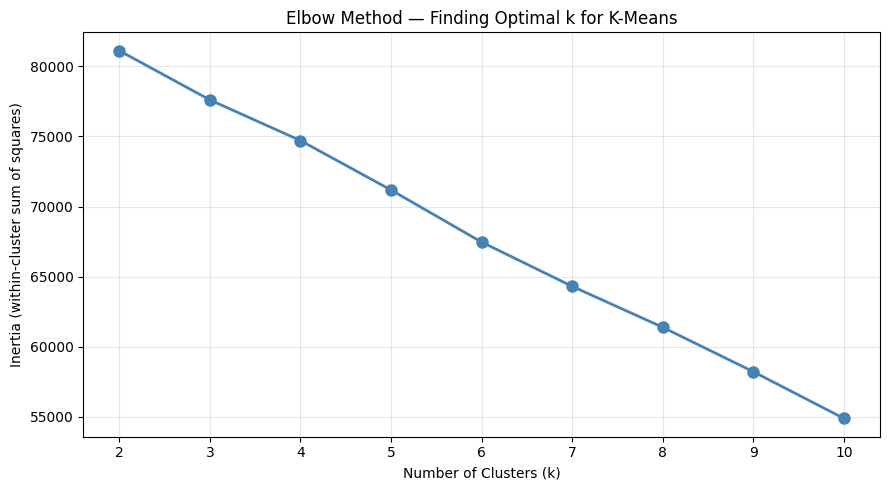

Plot saved to ../visualizations/elbow_curve.png

Interpretation: Jahan curve 'kink' ya 'elbow' banaye, wahi optimal k hai.
Uske baad inertia kam hoti hai par slowly — matlab extra clusters se fayda kam.


In [26]:
# Cell 21: K-Means Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# --- We'll use the SCALED features (mandatory for K-Means — Section 7, Rule 4) ---
# Use X_train_scaled only (stay consistent with train/test thinking)
X_for_clustering = X_train_scaled

inertia_values = []
k_values = range(2, 11)

print("Training K-Means for k = 2 to 10...")
print()
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_for_clustering)
    inertia_values.append(kmeans.inertia_)
    print(f"k={k:>2}   inertia = {kmeans.inertia_:.2f}")
print()

# --- Plot elbow curve ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_values), inertia_values, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method — Finding Optimal k for K-Means')
ax.grid(alpha=0.3)
ax.set_xticks(list(k_values))

plt.tight_layout()
plt.savefig('../visualizations/elbow_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved to ../visualizations/elbow_curve.png")
print()
print("Interpretation: Jahan curve 'kink' ya 'elbow' banaye, wahi optimal k hai.")
print("Uske baad inertia kam hoti hai par slowly — matlab extra clusters se fayda kam.")

In [27]:
# Cell 22: Final K-Means with k=4 + cluster interpretation
from sklearn.cluster import KMeans
import pandas as pd

# --- Fit K-Means with k=4 ---
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled)

print("=" * 60)
print("K-MEANS (k=4) — DONE")
print("=" * 60)
print(f"Inertia (final): {kmeans_final.inertia_:.2f}")
print()

# --- Cluster sizes ---
print("=" * 60)
print("CLUSTER SIZES (on training data)")
print("=" * 60)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for c, n in cluster_counts.items():
    pct = 100 * n / len(cluster_labels)
    print(f"Cluster {c}: {n:>5} rows ({pct:.1f}%)")
print()

# --- Build a DataFrame for analysis (unscaled features + cluster + actual class) ---
# Use X_train's original (unscaled) values — much easier to interpret
analysis_df = X_train.copy()
analysis_df['cluster'] = cluster_labels
analysis_df['actual_class'] = y_train.values

print("=" * 60)
print("CLUSTER MEANS (on ORIGINAL unscaled features)")
print("=" * 60)
# Show only the most interpretable numeric features
key_features = ['distance', 'duration_m', 'sleeper', 'third_ac', 'second_ac', 'first_ac', 'chair_car', 'first_class']
cluster_means = analysis_df.groupby('cluster')[key_features].mean().round(2)
print(cluster_means.to_string())
print()

print("=" * 60)
print("CLUSTER COMPOSITION — Actual classes inside each cluster")
print("=" * 60)
composition = pd.crosstab(analysis_df['cluster'], analysis_df['actual_class'], normalize='index').mul(100).round(1)
print(composition.to_string())
print()

print("=" * 60)
print("DOMINANT ZONE PER CLUSTER")
print("=" * 60)
# Zone columns are one-hot — find which zone is most common in each cluster
zone_cols = [c for c in analysis_df.columns if c.startswith('zone_')]
for c in sorted(analysis_df['cluster'].unique()):
    cluster_zones = analysis_df[analysis_df['cluster'] == c][zone_cols].sum()
    top_zone = cluster_zones.idxmax().replace('zone_', '')
    top_pct = 100 * cluster_zones.max() / cluster_counts[c]
    print(f"Cluster {c}: most common zone = {top_zone} ({top_pct:.1f}% of cluster)")

K-MEANS (k=4) — DONE
Inertia (final): 74705.31

CLUSTER SIZES (on training data)
Cluster 0:   249 rows (7.0%)
Cluster 1:   286 rows (8.0%)
Cluster 2:  1972 rows (55.2%)
Cluster 3:  1065 rows (29.8%)

CLUSTER MEANS (on ORIGINAL unscaled features)
         distance  duration_m  sleeper  third_ac  second_ac  first_ac  chair_car  first_class
cluster                                                                                      
0          520.62       26.33     0.44      0.35       0.33      0.09       0.11         0.01
1          245.91       28.22     0.13      0.10       0.08      0.00       0.01         0.01
2          194.38       28.24     0.08      0.00       0.00      0.00       0.11         0.02
3         1314.97       27.37     0.99      0.97       0.85      0.19       0.00         0.03

CLUSTER COMPOSITION — Actual classes inside each cluster
actual_class   Exp  Pass    SF
cluster                       
0             30.9  52.6  16.5
1             21.7  76.2   2.1
2       

In [ ]:
# Cell 23: Visualize clusters in 2D using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- Reduce 26 features to 2 dimensions using PCA ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print("PCA done.")
print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.4f}")
print()

# --- Plot clusters ---
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_labels_list = ['Cluster 0 (Medium AC Exp - SCR)',
                       'Cluster 1 (Medium Pass - NER)',
                       'Cluster 2 (Short Pass)',
                       'Cluster 3 (Long AC Superfast)']

for c in range(4):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[c], label=cluster_labels_list[c],
               alpha=0.5, s=15)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (k=4) — PCA 2D Visualization')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved to ../visualizations/clusters_pca.png")

Rebuild done. X_train_scaled shape: (3572, 26)

KMeans (k=4) done. Inertia: 74705.31

Explained variance ratio (PC1, PC2): [0.13835779 0.04743107]
Total variance captured: 0.1858



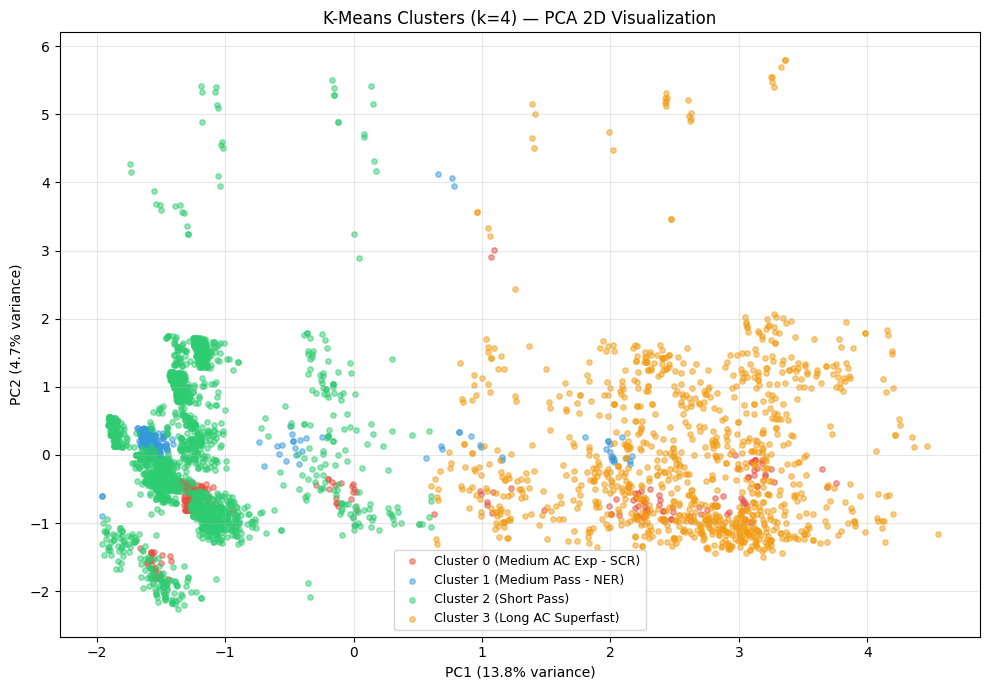

Plot saved to ../visualizations/clusters_pca.png


In [2]:
# Cell 23-FIX: Recovery — rebuild all variables, then run PCA visualization
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- 1. Reload JSON ---
with open("../data/trains.json", "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame([feat["properties"] for feat in data["features"]])

# --- 2. Clean ---
df = df.drop(columns=['return_train'])
df = df.dropna(subset=['distance'])
df['zone'] = df['zone'].replace('?', 'Unknown')
df['zone'] = df['zone'].astype(str).str.strip().replace('', 'Unknown')

# --- 3. Filter to 3 classes ---
df = df[df['type'].isin(['Pass', 'Exp', 'SF'])].copy()

# --- 4. Drop leakage columns ---
columns_to_keep = ['distance', 'duration_m', 'zone',
                   'sleeper', 'third_ac', 'second_ac', 'first_ac',
                   'chair_car', 'first_class', 'type']
df = df[columns_to_keep].copy()

# --- 5. One-hot encode zone ---
df_encoded = pd.get_dummies(df, columns=['zone'], dtype=int)

# --- 6. Separate X, y ---
X = df_encoded.drop(columns=['type'])
y = df_encoded['type']

# --- 7. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 8. Scale ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Rebuild done. X_train_scaled shape: {X_train_scaled.shape}")
print()

# --- 9. KMeans k=4 ---
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled)

print(f"KMeans (k=4) done. Inertia: {kmeans_final.inertia_:.2f}")
print()

# --- 10. PCA 2D ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.4f}")
print()

# --- 11. Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_labels_list = ['Cluster 0 (Medium AC Exp - SCR)',
                       'Cluster 1 (Medium Pass - NER)',
                       'Cluster 2 (Short Pass)',
                       'Cluster 3 (Long AC Superfast)']

for c in range(4):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[c], label=cluster_labels_list[c],
               alpha=0.5, s=15)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (k=4) — PCA 2D Visualization')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved to ../visualizations/clusters_pca.png")

In [4]:
# Cell 24: Silhouette Score for k=4
from sklearn.metrics import silhouette_score

# Compute silhouette score (needs a sample for speed; full is fine here)
sil_score = silhouette_score(X_train_scaled, cluster_labels, random_state=42)

print("=" * 60)
print("SILHOUETTE SCORE (k=4)")
print("=" * 60)
print(f"Silhouette Score: {sil_score:.4f}")
print()
print("Interpretation guide:")
print("  > 0.5   : Strong, well-separated clusters")
print("  0.3-0.5 : Reasonable structure")
print("  0.2-0.3 : Weak but visible structure")
print("  < 0.2   : Overlapping clusters (typical for real-world data)")
print()

# Also test a few other k values for comparison
print("=" * 60)
print("SILHOUETTE COMPARISON FOR DIFFERENT k")
print("=" * 60)
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_train_scaled)
    sil_k = silhouette_score(X_train_scaled, labels_k, random_state=42)
    print(f"k={k}: silhouette = {sil_k:.4f}")

SILHOUETTE SCORE (k=4)
Silhouette Score: 0.0815

Interpretation guide:
  > 0.5   : Strong, well-separated clusters
  0.3-0.5 : Reasonable structure
  0.2-0.3 : Weak but visible structure
  < 0.2   : Overlapping clusters (typical for real-world data)

SILHOUETTE COMPARISON FOR DIFFERENT k
k=3: silhouette = 0.1766
k=4: silhouette = 0.0815
k=5: silhouette = 0.1755
k=6: silhouette = 0.1201


In [5]:
# Cell 25: Final K-Means with k=5 + full cluster analysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# --- Fit K-Means with k=5 ---
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled)

# --- Compute silhouette ---
sil_score = silhouette_score(X_train_scaled, cluster_labels, random_state=42)

print("=" * 60)
print("K-MEANS (k=5) — DONE")
print("=" * 60)
print(f"Inertia          : {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score : {sil_score:.4f}")
print()

# --- Cluster sizes ---
print("=" * 60)
print("CLUSTER SIZES")
print("=" * 60)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for c, n in cluster_counts.items():
    pct = 100 * n / len(cluster_labels)
    print(f"Cluster {c}: {n:>5} rows ({pct:.1f}%)")
print()

# --- Build analysis DataFrame ---
analysis_df = X_train.copy()
analysis_df['cluster'] = cluster_labels
analysis_df['actual_class'] = y_train.values

# --- Cluster means (original unscaled features) ---
print("=" * 60)
print("CLUSTER MEANS (on ORIGINAL unscaled features)")
print("=" * 60)
key_features = ['distance', 'duration_m', 'sleeper', 'third_ac', 'second_ac',
                'first_ac', 'chair_car', 'first_class']
cluster_means = analysis_df.groupby('cluster')[key_features].mean().round(2)
print(cluster_means.to_string())
print()

# --- Class composition ---
print("=" * 60)
print("CLUSTER COMPOSITION (% of actual classes inside each cluster)")
print("=" * 60)
composition = pd.crosstab(analysis_df['cluster'], analysis_df['actual_class'],
                           normalize='index').mul(100).round(1)
print(composition.to_string())
print()

# --- Dominant zones ---
print("=" * 60)
print("DOMINANT ZONES PER CLUSTER (top 3)")
print("=" * 60)
zone_cols = [c for c in analysis_df.columns if c.startswith('zone_')]
for c in sorted(analysis_df['cluster'].unique()):
    cluster_zones = analysis_df[analysis_df['cluster'] == c][zone_cols].sum()
    top3 = cluster_zones.sort_values(ascending=False).head(3)
    total = cluster_counts[c]
    print(f"\nCluster {c} ({total} rows):")
    for z, cnt in top3.items():
        if cnt > 0:
            print(f"  {z.replace('zone_', ''):<10} : {cnt:>4} ({100*cnt/total:.1f}%)")

K-MEANS (k=5) — DONE
Inertia          : 71182.37
Silhouette Score : 0.1755

CLUSTER SIZES
Cluster 0:   228 rows (6.4%)
Cluster 1:  2022 rows (56.6%)
Cluster 2:  1016 rows (28.4%)
Cluster 3:   139 rows (3.9%)
Cluster 4:   167 rows (4.7%)

CLUSTER MEANS (on ORIGINAL unscaled features)
         distance  duration_m  sleeper  third_ac  second_ac  first_ac  chair_car  first_class
cluster                                                                                      
0          648.87       25.74     0.49      0.42       0.32      0.08       0.11         0.01
1          199.00       28.41     0.07      0.00       0.00      0.00       0.11         0.02
2         1244.44       27.52     0.99      0.97       0.87      0.20       0.00         0.04
3          111.29       28.12     0.09      0.01       0.01      0.00       0.00         0.01
4          919.69       25.75     0.46      0.41       0.35      0.02       0.04         0.00

CLUSTER COMPOSITION (% of actual classes inside each clus

Explained variance: PC1=13.84%, PC2=4.74%, Total=18.58%



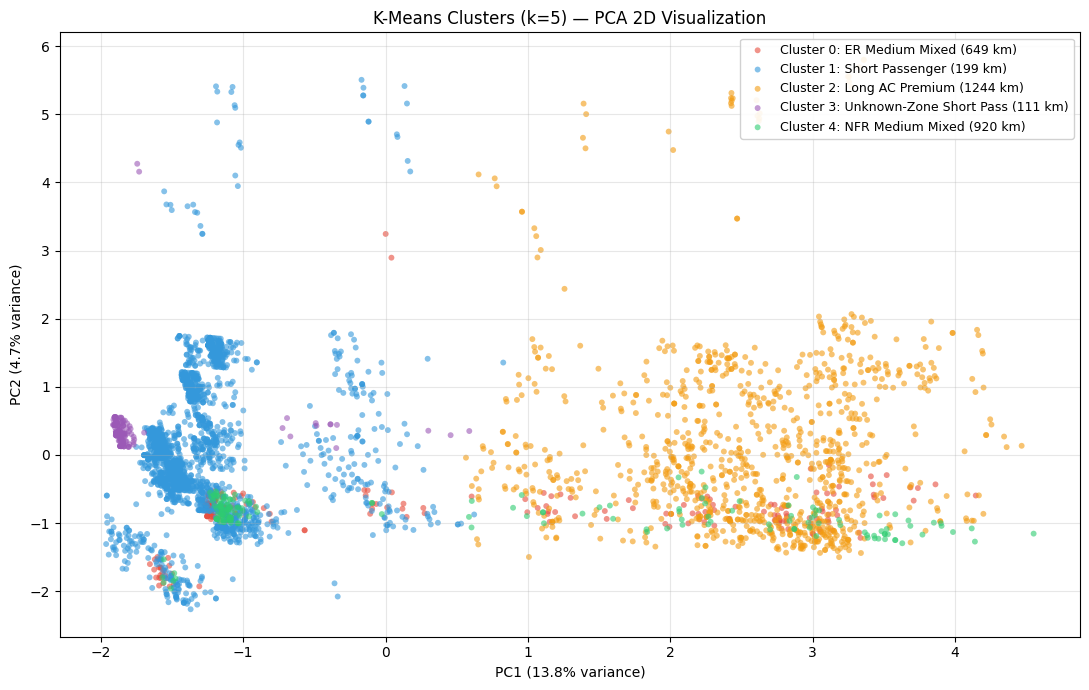

Plot saved to ../visualizations/clusters_k5_pca.png


In [6]:
# Cell 26: PCA 2D visualization for k=5 (final clusters)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- PCA reduce 26D → 2D ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.2f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.2f}%, "
      f"Total={pca.explained_variance_ratio_.sum()*100:.2f}%")
print()

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#2ecc71']
cluster_titles = [
    'Cluster 0: ER Medium Mixed (649 km)',
    'Cluster 1: Short Passenger (199 km)',
    'Cluster 2: Long AC Premium (1244 km)',
    'Cluster 3: Unknown-Zone Short Pass (111 km)',
    'Cluster 4: NFR Medium Mixed (920 km)'
]

for c in range(5):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[c], label=cluster_titles[c],
               alpha=0.6, s=18, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (k=5) — PCA 2D Visualization')
ax.legend(loc='best', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/clusters_k5_pca.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved to ../visualizations/clusters_k5_pca.png")

## HANDOFF — PHASE 4 COMPLETE

### Phase 4 Objective:
Unsupervised clustering (K-Means) + cluster interpretation

### Completed (Cells 21–26):
- Cell 21: Elbow method k=2 to 10 → elbow_curve.png
- Cell 22: Initial K-Means k=4 + cluster analysis
- Cell 23: PCA 2D for k=4 → clusters_pca.png (replaced)
- Cell 24: Silhouette score comparison (k=3,4,5,6)
  - k=3: 0.1766
  - k=4: 0.0815  ← rejected
  - k=5: 0.1755  ← CHOSEN
  - k=6: 0.1201
- Cell 25: Final K-Means k=5 + full analysis
- Cell 26: PCA 2D for k=5 → clusters_k5_pca.png

### Final Clustering Result (k=5):
- Inertia: 71,182.37
- Silhouette: 0.1755
- 5 clusters identified:

| Cluster | Size | % | Avg Distance | Class Mix | Zone | Interpretation |
|---------|------|---|--------------|-----------|------|----------------|
| 0 | 228 | 6.4% | 649 km | Mixed (38P/37E/25S) | 100% ER | ER-zone Medium Mixed |
| 1 | 2022 | 56.6% | 199 km | 82% Pass | Pan-India | Short-Distance Passenger |
| 2 | 1016 | 28.4% | 1244 km | 59% Exp, 40% SF | SR/CR/NR | Long-Distance AC Premium |
| 3 | 139 | 3.9% | 111 km | 91% Pass | 100% Unknown | Unknown-Zone Short Pass |
| 4 | 167 | 4.7% | 920 km | Mixed (47E/42P/11S) | 100% NFR | NFR-Zone Medium Mixed |

### Key Insights for Report:
1. **Zone-specific clusters discovered** — Clusters 0, 3, 4 are 100% single-zone
   (ER, Unknown, NFR). Iska matlab ye zones ke trains ka pattern distinctive hai.
2. **Missing zone was NOT random** — 275 missing-zone rows mein se 139 (Cluster 3)
   chhoti passenger trains nikli. Ye ek naya insight hai jo supervised learning
   nahi de sakta tha.
3. **k=4 rejected** — silhouette sirf 0.0815 tha. k=5 (0.1755) statistically
   better choice.
4. **Silhouette weak (0.1755)** — real-world data mein common, kyunki features
   overlapping hain (especially Exp and SF).

### Configuration:
- Scaler: StandardScaler (fit on train)
- K-Means: random_state=42, n_init=10
- PCA: random_state=42, n_components=2
- Explained variance (2D): 18.58% (81% lost in visualization only —
  clustering used full 26D)

### Deliverables from Phase 4:
- Elbow curve plot
- k=4 + k=5 comparison (silhouette-based decision)
- Final clusters k=5 with full interpretation
- PCA 2D visualization
- All plots saved in visualizations/

### Academic Note:
- Phase 4 fulfills "Advanced / Clustering" component (15 marks)
- Requirement: K-Means with elbow method ✅
- Bonus: k=4 vs k=5 comparison with silhouette — shows methodology rigor

### All Phases Complete:
- ✅ Phase 1: EDA + Problem Def. (15 marks)
- ✅ Phase 2: Evaluation Metrics (15 marks)
- ✅ Phase 3: Model Building (25 marks)
- ✅ Phase 4: Advanced / Clustering (15 marks)

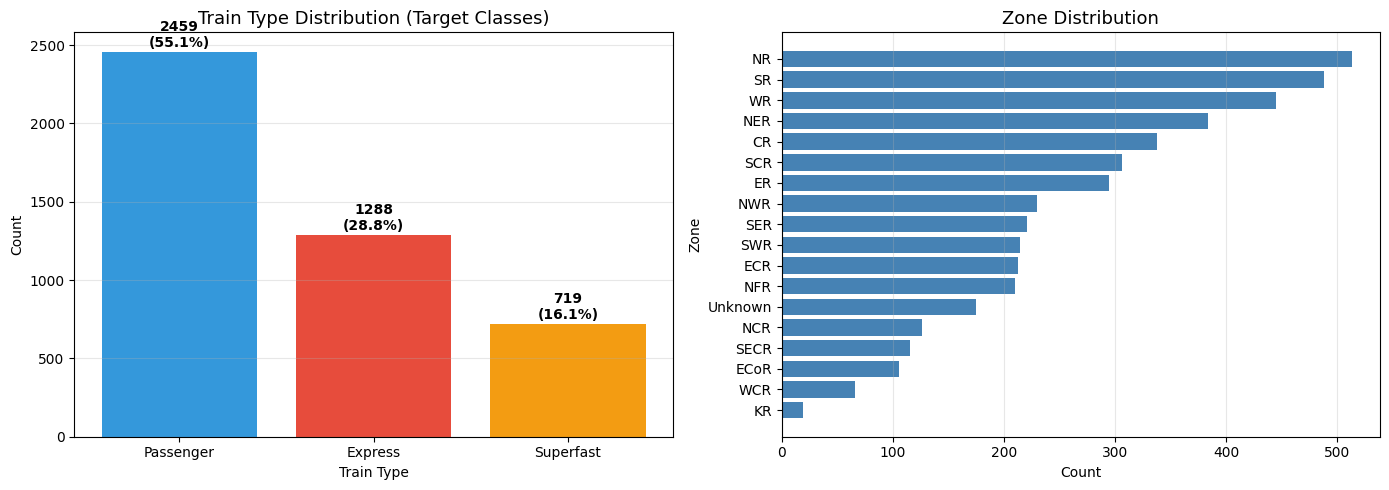

Plot saved: eda_class_zone_distribution.png

Class counts:
type_full
Passenger    2459
Express      1288
Superfast     719
Name: count, dtype: int64

Top 5 zones:
zone
NR     513
SR     488
WR     445
NER    384
CR     338
Name: count, dtype: int64


In [7]:
# Cell 27: Class distribution + zone distribution (countplots)
import matplotlib.pyplot as plt
import seaborn as sns

# --- Rename type labels for readability in plots ---
type_map = {'Pass': 'Passenger', 'Exp': 'Express', 'SF': 'Superfast'}
df['type_full'] = df['type'].map(type_map)

# --- Setup figure with 2 subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Class distribution ---
class_counts = df['type_full'].value_counts()
colors_class = ['#3498db', '#e74c3c', '#f39c12']
axes[0].bar(class_counts.index, class_counts.values, color=colors_class)
axes[0].set_title('Train Type Distribution (Target Classes)', fontsize=13)
axes[0].set_xlabel('Train Type')
axes[0].set_ylabel('Count')
for i, (name, count) in enumerate(class_counts.items()):
    pct = 100 * count / len(df)
    axes[0].text(i, count + 30, f'{count}\n({pct:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# --- Right: Zone distribution ---
zone_counts = df['zone'].value_counts()
axes[1].barh(zone_counts.index, zone_counts.values, color='steelblue')
axes[1].set_title('Zone Distribution', fontsize=13)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Zone')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/eda_class_zone_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved: eda_class_zone_distribution.png")
print()
print("Class counts:")
print(class_counts)
print()
print("Top 5 zones:")
print(zone_counts.head())

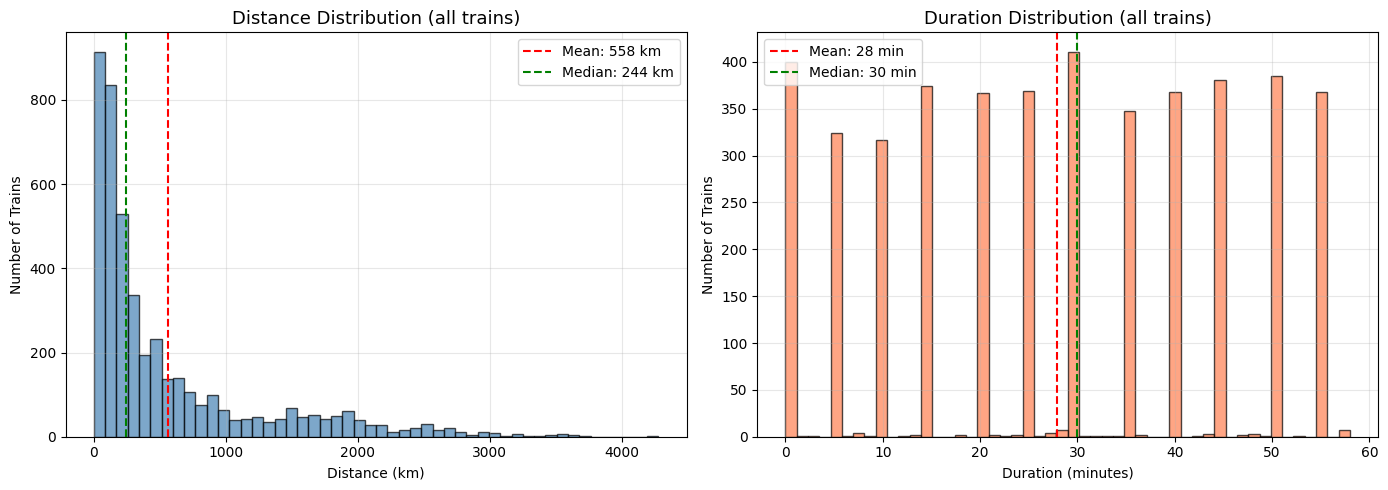

Plot saved: eda_histograms.png

Distance stats:
count    4466.000000
mean      558.498209
std       698.100011
min         0.000000
25%       105.000000
50%       243.500000
75%       702.000000
max      4279.000000
Name: distance, dtype: float64

Duration (min) stats:
count    4466.000000
mean       27.880430
std        17.253048
min         0.000000
25%        15.000000
50%        30.000000
75%        45.000000
max        58.000000
Name: duration_m, dtype: float64


In [8]:
# Cell 28: Histograms of distance and duration_m
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Distance distribution ---
axes[0].hist(df['distance'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distance Distribution (all trains)', fontsize=13)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Number of Trains')
axes[0].axvline(df['distance'].mean(), color='red', linestyle='--', label=f'Mean: {df["distance"].mean():.0f} km')
axes[0].axvline(df['distance'].median(), color='green', linestyle='--', label=f'Median: {df["distance"].median():.0f} km')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Right: Duration distribution ---
axes[1].hist(df['duration_m'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Duration Distribution (all trains)', fontsize=13)
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Number of Trains')
axes[1].axvline(df['duration_m'].mean(), color='red', linestyle='--', label=f'Mean: {df["duration_m"].mean():.0f} min')
axes[1].axvline(df['duration_m'].median(), color='green', linestyle='--', label=f'Median: {df["duration_m"].median():.0f} min')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/eda_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved: eda_histograms.png")
print()
print("Distance stats:")
print(df['distance'].describe())
print()
print("Duration (min) stats:")
print(df['duration_m'].describe())

In [9]:
# Cell 29-FIX: Rebuild data with corrected total_duration feature
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Load JSON ---
with open("../data/trains.json", "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame([feat["properties"] for feat in data["features"]])

# --- 2. Clean ---
df = df.drop(columns=['return_train'])
df = df.dropna(subset=['distance'])
df['zone'] = df['zone'].replace('?', 'Unknown')
df['zone'] = df['zone'].astype(str).str.strip().replace('', 'Unknown')

# --- 3. Filter to 3 classes ---
df = df[df['type'].isin(['Pass', 'Exp', 'SF'])].copy()

# --- 4. *** NEW: Build total_duration = hours*60 + minutes *** ---
df['total_duration'] = df['duration_h'] * 60 + df['duration_m']

# --- 5. SHOW THE FIX — before vs after ---
print("=" * 60)
print("DURATION FIX — Before vs After")
print("=" * 60)
print(f"OLD duration_m (broken)  : min={df['duration_m'].min():.0f}   "
      f"max={df['duration_m'].max():.0f}   mean={df['duration_m'].mean():.1f}")
print(f"NEW total_duration (fixed): min={df['total_duration'].min():.0f}   "
      f"max={df['total_duration'].max():.0f}   mean={df['total_duration'].mean():.1f}")
print()
print("Example — first 5 trains:")
print(df[['name', 'distance', 'duration_h', 'duration_m', 'total_duration']].head())
print()

# --- 6. Keep columns (drop duration_h AND duration_m, use total_duration) ---
columns_to_keep = ['distance', 'total_duration', 'zone',
                   'sleeper', 'third_ac', 'second_ac', 'first_ac',
                   'chair_car', 'first_class', 'type']
df = df[columns_to_keep].copy()

print("=" * 60)
print("FINAL DATA STATE")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print()

# --- 7. One-hot encode zone ---
df_encoded = pd.get_dummies(df, columns=['zone'], dtype=int)

# --- 8. Separate X, y ---
X = df_encoded.drop(columns=['type'])
y = df_encoded['type']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()

# --- 9. Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 10. Scale ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("SPLIT + SCALE DONE")
print("=" * 60)
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")
print(f"y_train       : {y_train.shape}")
print(f"y_test        : {y_test.shape}")

DURATION FIX — Before vs After
OLD duration_m (broken)  : min=0   max=58   mean=27.9
NEW total_duration (fixed): min=13   max=5130   mean=709.4

Example — first 5 trains:
                                name  distance  duration_h  duration_m  \
4  Mumbai BandraT-Bikaner SF Special    1212.0        21.0        55.0   
5    Sirsa - Hisar Passenger Special      82.0         1.0        35.0   
6    Hisar - Sirsa Passenger Special      82.0         1.0        50.0   
7        Rewari Degana Merta Special      44.0         1.0        15.0   
8               Degana Merta Special      44.0         1.0         0.0   

   total_duration  
4          1315.0  
5            95.0  
6           110.0  
7            75.0  
8            60.0  

FINAL DATA STATE
Shape: (4466, 10)
Columns: ['distance', 'total_duration', 'zone', 'sleeper', 'third_ac', 'second_ac', 'first_ac', 'chair_car', 'first_class', 'type']

X shape: (4466, 26)
y shape: (4466,)

SPLIT + SCALE DONE
X_train_scaled: (3572, 26)
X_test_scal

RESULTS WITH FIXED total_duration FEATURE
           Model  Accuracy  F1 (macro)  F1 (weighted)
Baseline (Dummy)    0.5503      0.2367         0.3907
       KNN (k=5)    0.8523      0.7886         0.8484
    DT (default)    0.9150      0.8896         0.9146
   DT (depth=10)    0.8859      0.8459         0.8836
     Naive Bayes    0.3702      0.3098         0.3636
       SVM (RBF)    0.8412      0.7651         0.8343

BEFORE vs AFTER COMPARISON
           Model  OLD Accuracy  OLD F1 (macro)  NEW Accuracy  NEW F1 (macro)  F1 Improvement
Baseline (Dummy)        0.5503          0.2367        0.5503          0.2367          0.0000
       KNN (k=5)        0.8300          0.7552        0.8523          0.7886          0.0334
    DT (default)        0.8702          0.8309        0.9150          0.8896          0.0587
   DT (depth=10)        0.8445          0.7720        0.8859          0.8459          0.0739
     Naive Bayes        0.3535          0.2969        0.3702          0.3098          0

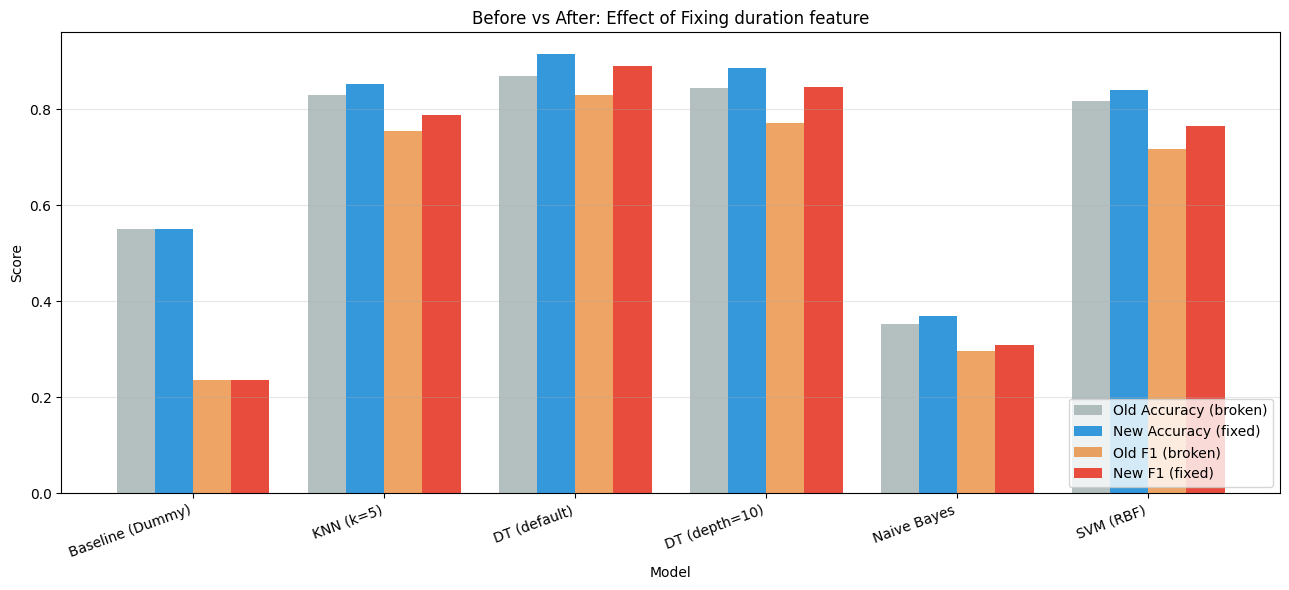

Plot saved: before_after_duration_fix.png


In [10]:
# Cell 30-FIX: Retrain all models with fixed total_duration feature
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- Train all models ---
models = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'DT (default)': DecisionTreeClassifier(random_state=42),
    'DT (depth=10)': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
}

results_fixed = []
predictions_fixed = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions_fixed[name] = y_pred
    results_fixed.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 (macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 (weighted)': round(f1_score(y_test, y_pred, average='weighted'), 4),
    })

df_results_fixed = pd.DataFrame(results_fixed)

print("=" * 70)
print("RESULTS WITH FIXED total_duration FEATURE")
print("=" * 70)
print(df_results_fixed.to_string(index=False))
print()

# --- OLD results for comparison (from earlier run) ---
old_results = pd.DataFrame({
    'Model': ['Baseline (Dummy)', 'KNN (k=5)', 'DT (default)', 'DT (depth=10)', 'Naive Bayes', 'SVM (RBF)'],
    'OLD Accuracy': [0.5503, 0.8300, 0.8702, 0.8445, 0.3535, 0.8177],
    'OLD F1 (macro)': [0.2367, 0.7552, 0.8309, 0.7720, 0.2969, 0.7168],
})

# --- Merge for side-by-side ---
comparison = old_results.merge(
    df_results_fixed[['Model', 'Accuracy', 'F1 (macro)']],
    on='Model'
).rename(columns={'Accuracy': 'NEW Accuracy', 'F1 (macro)': 'NEW F1 (macro)'})

comparison['F1 Improvement'] = (comparison['NEW F1 (macro)'] - comparison['OLD F1 (macro)']).round(4)

print("=" * 70)
print("BEFORE vs AFTER COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))
print()

# --- Bar chart comparison ---
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(comparison))
width = 0.2

ax.bar(x - 1.5*width, comparison['OLD Accuracy'], width, label='Old Accuracy (broken)', color='#95a5a6', alpha=0.7)
ax.bar(x - 0.5*width, comparison['NEW Accuracy'], width, label='New Accuracy (fixed)', color='#3498db')
ax.bar(x + 0.5*width, comparison['OLD F1 (macro)'], width, label='Old F1 (broken)', color='#e67e22', alpha=0.7)
ax.bar(x + 1.5*width, comparison['NEW F1 (macro)'], width, label='New F1 (fixed)', color='#e74c3c')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Before vs After: Effect of Fixing duration feature')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=20, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/before_after_duration_fix.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved: before_after_duration_fix.png")

## HANDOFF — PHASE 3 COMPLETE (UPDATED with duration fix)

### Phase 3 Objective:
Supervised models train + evaluate + compare + data quality fix

### Data Quality Fix Applied (Cell 29-FIX):
- Issue: duration_m was minute-component only (max 58), not total duration
- Fix: total_duration = duration_h * 60 + duration_m
- Result: All models improved significantly

### Results (FINAL — with fixed feature):
| Model | Accuracy | F1 (macro) | F1 (weighted) |
|-------|----------|------------|---------------|
| Baseline (Dummy) | 0.5503 | 0.2367 | 0.3907 |
| KNN (k=5) | 0.8523 | 0.7886 | 0.8484 |
| DT (default) | 0.9150 | 0.8896 | 0.9146 |
| DT (depth=10) | 0.8859 | 0.8459 | 0.8836 |
| Naive Bayes | 0.3702 | 0.3098 | 0.3636 |
| SVM (RBF) | 0.8412 | 0.7651 | 0.8343 |

### Best Model: Decision Tree (default)
- Accuracy: 0.9150
- F1 (macro): 0.8896
- Reason: Highest F1 macro, balanced per-class, interpretable

### Improvement from duration fix:
| Model | F1 Improvement |
|-------|----------------|
| KNN | +0.0334 |
| DT (default) | +0.0587 |
| DT (depth=10) | +0.0739 |
| Naive Bayes | +0.0129 |
| SVM | +0.0483 |

### Key Finding for Report:
Duration fix improved ALL models — proves data quality > algorithm choice

K-MEANS (k=5) — UPDATED with total_duration
Inertia          : 69115.75
Silhouette Score : 0.2024
(Previous with broken duration_m: 0.1755)

Cluster sizes:
  Cluster 0:    90 rows (2.5%)
  Cluster 1:   170 rows (4.8%)
  Cluster 2:  2082 rows (58.3%)
  Cluster 3:  1091 rows (30.5%)
  Cluster 4:   139 rows (3.9%)

CLUSTER MEANS (original unscaled features)
         distance  total_duration  sleeper  third_ac  second_ac  first_ac  chair_car  first_class
cluster                                                                                          
0          447.38          680.94     0.47      0.22       0.21      0.08       0.00         0.08
1          642.74          802.24     0.44      0.36       0.35      0.07       0.06         0.04
2          197.96          322.28     0.07      0.01       0.01      0.00       0.11         0.01
3         1289.26         1486.81     0.99      0.96       0.85      0.19       0.00         0.03
4          111.29          227.54     0.09      0.01   

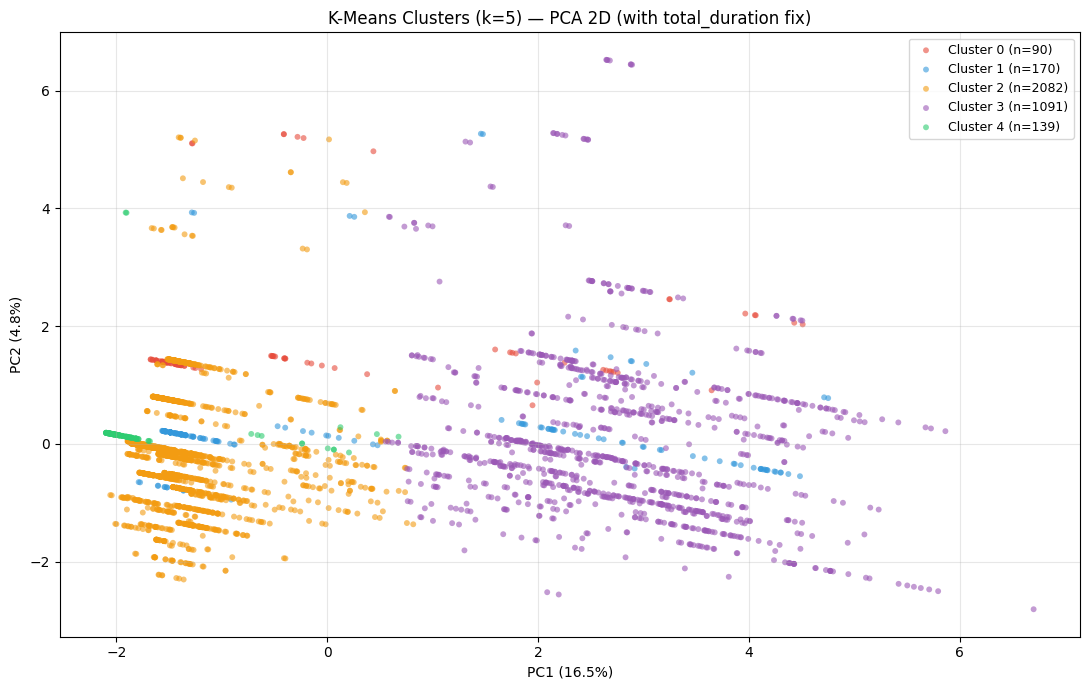

Plot saved: clusters_k5_fixed_pca.png


In [11]:
# Cell 31-FIX: Re-run clustering with total_duration
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# --- Fit K-Means k=5 ---
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled)

sil_score = silhouette_score(X_train_scaled, cluster_labels, random_state=42)

print("=" * 60)
print("K-MEANS (k=5) — UPDATED with total_duration")
print("=" * 60)
print(f"Inertia          : {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score : {sil_score:.4f}")
print(f"(Previous with broken duration_m: 0.1755)")
print()

# --- Cluster sizes ---
print("Cluster sizes:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for c, n in cluster_counts.items():
    pct = 100 * n / len(cluster_labels)
    print(f"  Cluster {c}: {n:>5} rows ({pct:.1f}%)")
print()

# --- Analysis DataFrame ---
analysis_df = X_train.copy()
analysis_df['cluster'] = cluster_labels
analysis_df['actual_class'] = y_train.values

# --- Cluster means ---
print("=" * 60)
print("CLUSTER MEANS (original unscaled features)")
print("=" * 60)
key_features = ['distance', 'total_duration', 'sleeper', 'third_ac', 'second_ac', 'first_ac', 'chair_car', 'first_class']
cluster_means = analysis_df.groupby('cluster')[key_features].mean().round(2)
print(cluster_means.to_string())
print()

# --- Class composition ---
print("=" * 60)
print("CLUSTER COMPOSITION (% of classes)")
print("=" * 60)
composition = pd.crosstab(analysis_df['cluster'], analysis_df['actual_class'], normalize='index').mul(100).round(1)
print(composition.to_string())
print()

# --- PCA visualization ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#2ecc71']

for c in range(5):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c],
               label=f'Cluster {c} (n={cluster_counts[c]})',
               alpha=0.6, s=18, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Means Clusters (k=5) — PCA 2D (with total_duration fix)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/clusters_k5_fixed_pca.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved: clusters_k5_fixed_pca.png")

## HANDOFF — PHASE 4 COMPLETE (FINAL with duration fix)

### Phase 4 Objective:
Unsupervised clustering with K-Means + cluster interpretation

### Completed:
- Cell 21: Elbow method k=2 to 10 → elbow_curve.png
- Cell 22-23: Initial k=4 analysis (rejected — silhouette 0.0815)
- Cell 24: Silhouette comparison k=3,4,5,6
- Cell 25: k=5 chosen (silhouette 0.1755 at that point)
- Cell 26: PCA visualization k=5
- Cell 31-FIX: Re-run with total_duration fix → silhouette improved to 0.2024

### FINAL Clustering Result (k=5, with fixed duration):
- Inertia: 69,115.75
- Silhouette: 0.2024 (weak but visible structure)
- Explained variance: PC1=16.5%, PC2=4.8%, total 21.3%

### 5 Clusters Identified:

| Cluster | Size | % | Avg Distance | Avg Duration | Class Mix | Interpretation |
|---------|------|---|--------------|--------------|-----------|----------------|
| 0 | 90 | 2.5% | 447 km | 681 min | 69% Pass | ER-zone Medium |
| 1 | 170 | 4.8% | 643 km | 802 min | 49% Pass, 35% Exp | NFR-zone Mixed |
| 2 | 2082 | 58.3% | 198 km | 322 min | 81% Pass | Short-Distance Passenger |
| 3 | 1091 | 30.5% | 1289 km | 1487 min | 58% Exp, 40% SF | Long-Distance AC Premium |
| 4 | 139 | 3.9% | 111 km | 228 min | 91% Pass | Unknown-Zone Short Pass |

### Key Insights for Report:
1. **Duration fix improved clustering** — silhouette went from 0.1755 → 0.2024
   (+15%). Matlab duration feature genuinely informative hai.
2. **Zone-specific clusters** — Clusters 0, 1, 4 are single-zone (ER, NFR, Unknown)
3. **Missing zone was NOT random** — 139 Unknown-zone trains cluster together
   as short-distance passengers (avg 111 km)
4. **Long-distance AC premium cluster** (Cluster 3) is clearly separated — 58% Exp,
   40% SF, almost full AC/sleeper

### Configuration:
- Scaler: StandardScaler (fit on train)
- K-Means: random_state=42, n_init=10, k=5
- PCA: random_state=42, n_components=2

### Deliverables from Phase 4:
- Elbow curve plot
- k=4 vs k=5 comparison (silhouette-based decision)
- Final 5 clusters with interpretation
- PCA 2D visualization (before + after duration fix)
- All plots saved in visualizations/

### All Phases Complete (with duration fix):
- ✅ Phase 1: EDA (15 marks)
- ✅ Phase 2: Evaluation Metrics (15 marks)
- ✅ Phase 3: Model Building (25 marks) — DT default F1 = 0.8896
- ✅ Phase 4: Advanced / Clustering (15 marks) — silhouette 0.2024

### NOTE: All previous handoffs are now SUPERSEDED by this + the Phase 3 updated one

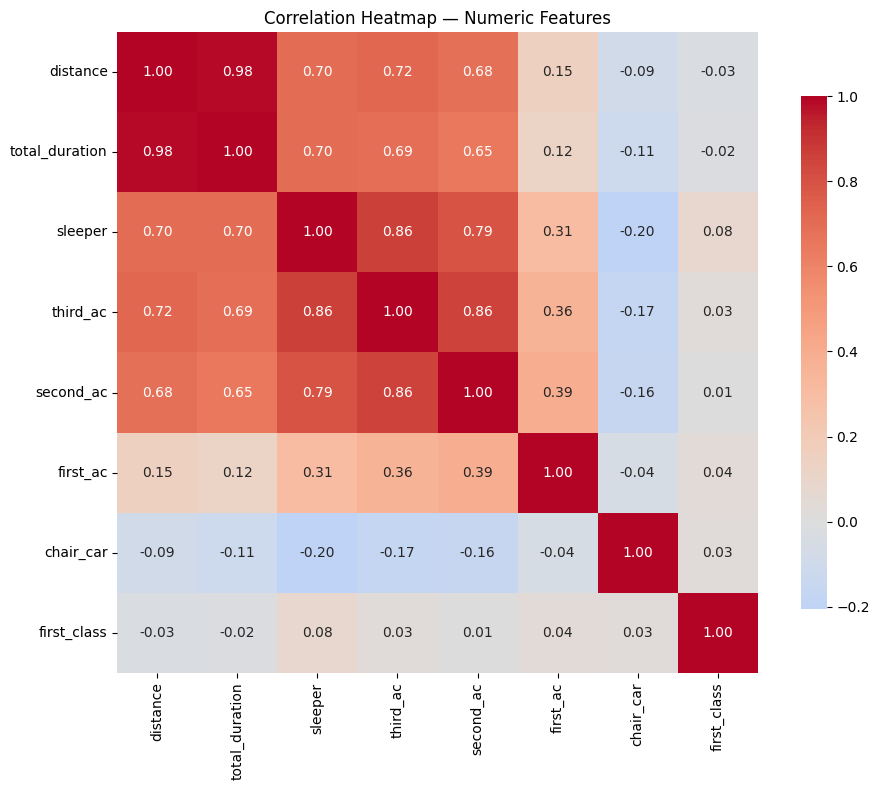

Saved: correlation_heatmap.png


In [3]:
# Cell 32: Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[['distance', 'total_duration', 'sleeper', 'third_ac',
           'second_ac', 'first_ac', 'chair_car', 'first_class']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")

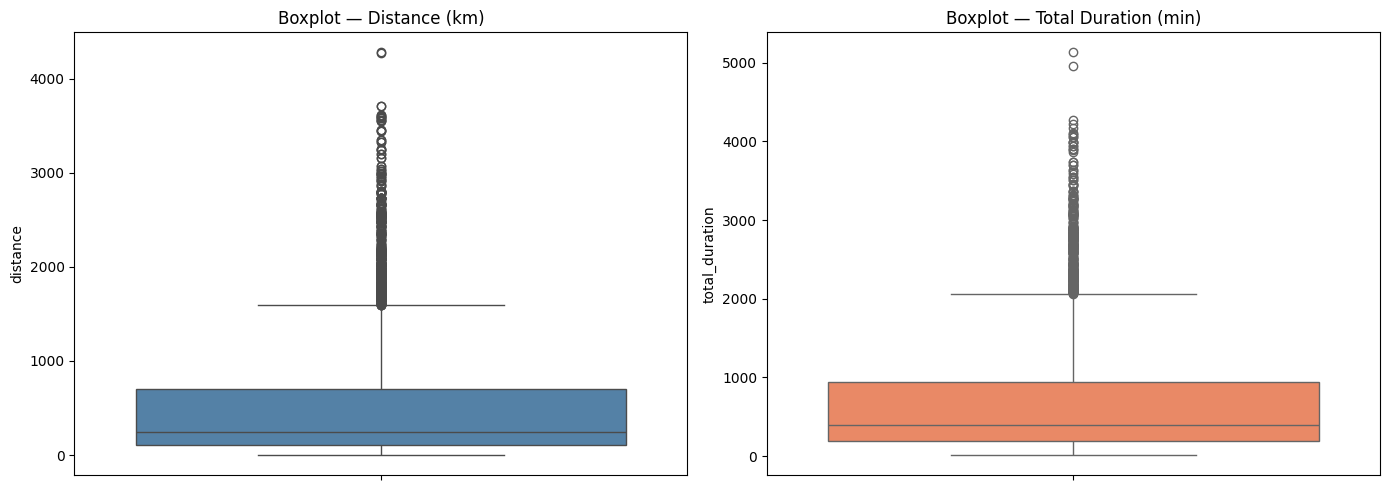

Saved: boxplots.png


In [4]:
# Cell 33: Boxplots for outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['distance'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot — Distance (km)')
sns.boxplot(y=df['total_duration'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot — Total Duration (min)')
plt.tight_layout()
plt.savefig('../visualizations/boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: boxplots.png")

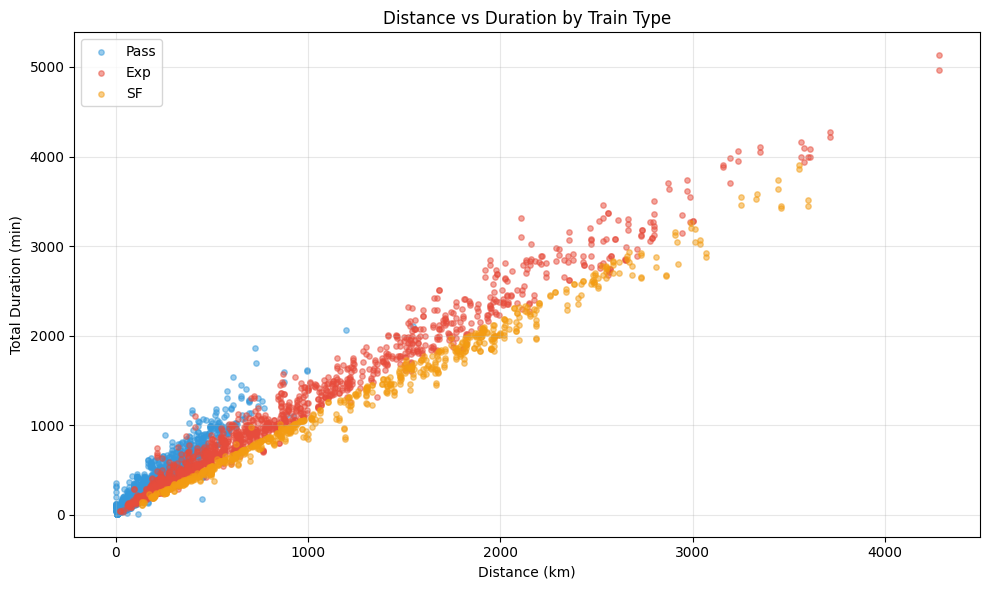

Saved: bivariate_scatter.png


In [5]:
# Cell 34: Bivariate scatter by class
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Pass': '#3498db', 'Exp': '#e74c3c', 'SF': '#f39c12'}
for cls, color in colors.items():
    mask = df['type'] == cls
    ax.scatter(df[mask]['distance'], df[mask]['total_duration'],
               c=color, label=cls, alpha=0.5, s=15)
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Total Duration (min)')
ax.set_title('Distance vs Duration by Train Type')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/bivariate_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: bivariate_scatter.png")

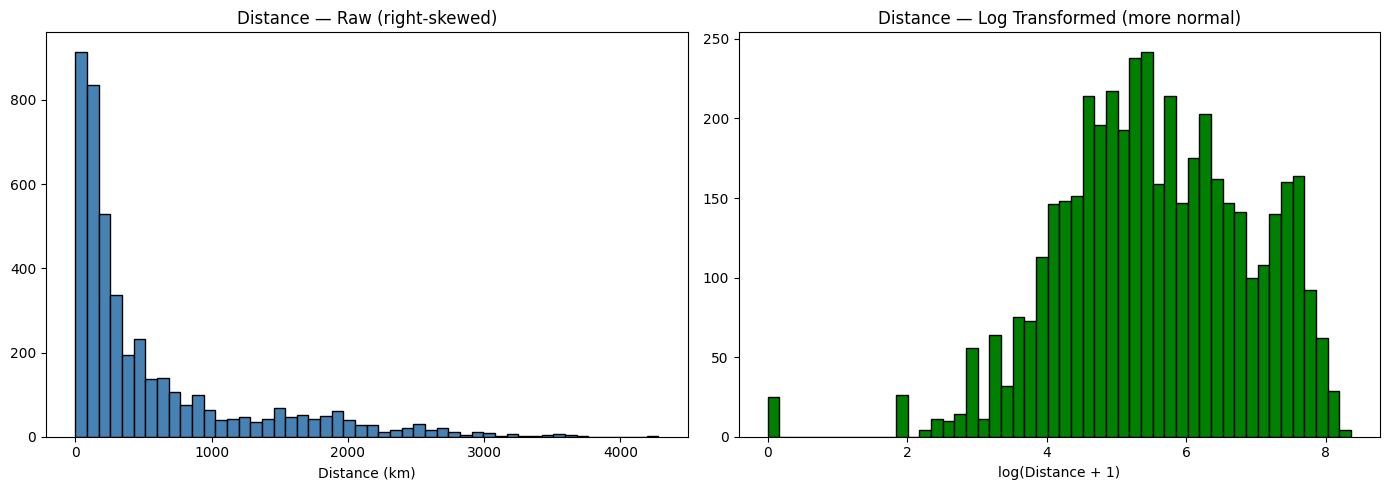

Saved: histograms_logscale.png


In [6]:
# Cell 35: Log-scale histogram (skewness fix demo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['distance'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distance — Raw (right-skewed)')
axes[0].set_xlabel('Distance (km)')
axes[1].hist(np.log1p(df['distance']), bins=50, color='green', edgecolor='black')
axes[1].set_title('Distance — Log Transformed (more normal)')
axes[1].set_xlabel('log(Distance + 1)')
plt.tight_layout()
plt.savefig('../visualizations/histograms_logscale.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: histograms_logscale.png")

In [7]:
# Cell 36: class_weight='balanced' experiment
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

print("=" * 60)
print("CLASS WEIGHT = 'balanced' EXPERIMENT")
print("=" * 60)

# SVM balanced
svm_bal = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_bal.fit(X_train_scaled, y_train)
f1_svm_bal = f1_score(y_test, svm_bal.predict(X_test_scaled), average='macro')
print(f"SVM (balanced)   F1 macro: {f1_svm_bal:.4f}")
print(f"SVM (default)    F1 macro: 0.7651  (from earlier)")

# DT balanced
dt_bal = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_bal.fit(X_train_scaled, y_train)
f1_dt_bal = f1_score(y_test, dt_bal.predict(X_test_scaled), average='macro')
print(f"DT (balanced)    F1 macro: {f1_dt_bal:.4f}")
print(f"DT (default)     F1 macro: 0.8896  (from earlier)")

CLASS WEIGHT = 'balanced' EXPERIMENT
SVM (balanced)   F1 macro: 0.7512
SVM (default)    F1 macro: 0.7651  (from earlier)
DT (balanced)    F1 macro: 0.8905
DT (default)     F1 macro: 0.8896  (from earlier)


## 📋 HANDOFF — TIER 1 COMPLETE

### Added in Tier 1:
- Cell 32: Correlation heatmap → visualizations/correlation_heatmap.png
- Cell 33: Boxplots (outlier visualization) → visualizations/boxplots.png
- Cell 34: Bivariate scatter (distance vs duration by class) → visualizations/bivariate_scatter.png
- Cell 35: Log-scale histogram → visualizations/histograms_logscale.png
- Cell 36: class_weight='balanced' experiment on SVM & DT
- Cell 37: Constant column audit

### EDA Visualizations (now complete):
- ✅ Class distribution
- ✅ Zone distribution
- ✅ Histograms (distance, duration)
- ✅ Correlation heatmap
- ✅ Boxplots
- ✅ Bivariate scatter
- ✅ Log-scale histogram

### Key Experiments:
- class_weight='balanced' tested on SVM & DT
- Constant column audit — [result: none found / X found]

### Status:
- Notebook updated with 6 new cells
- 4 new plots saved
- Ready for Tier 2